In [1]:
# ============================================================
# PHASE 9 — DNABERT-2 BEHAVIOUR DEEP DIVE
# Goal:
# 1. Understand why DNABERT-2 improves ROC-AUC but weaker enrichment.
# 2. Analyse rank shifts and score shifts between:
#    - Multimodal handcrafted: ProtBERT-SW + K3/K4/Basic
#    - Multimodal DNABERT-2: ProtBERT-SW + DNABERT-2
# 3. Identify moved-in / moved-out genes and their biological themes.
# 4. Generate figures and tables for professor/publication.
# ============================================================

import warnings
from pathlib import Path
from collections import defaultdict

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore")

pd.set_option("display.max_columns", 250)
pd.set_option("display.max_colwidth", 300)

SEED = 42
np.random.seed(SEED)

# ============================================================
# PROJECT PATHS
# ============================================================

import os
from pathlib import Path
import pandas as pd
from google.colab import drive

try:
    drive.mount('/content/drive')
except ValueError:
    print("Drive đã được kết nối từ trước.")

PROJECT_DIR = Path("/content/drive/MyDrive/Project_Protein")

# Previous phases
PHASE7_DIR = PROJECT_DIR / "model" / "phase7_statistical_evidence"
PHASE7_RESULT_DIR = PHASE7_DIR / "results"

PHASE8_DIR = PROJECT_DIR / "model" / "phase8_expanded_biological_validation"
PHASE8_RESULT_DIR = PHASE8_DIR / "results"
PHASE8_GENE_LIST_DIR = PHASE8_DIR / "gene_lists"
PHASE8_ENRICHMENT_DIR = PHASE8_DIR / "enrichment_results"

# New Phase 9 outputs
PHASE9_DIR = PROJECT_DIR / "model" / "phase9_dnabert2_behaviour_deep_dive"
RESULT_DIR = PHASE9_DIR / "results"
FIGURE_DIR = PHASE9_DIR / "figures"
EXCEL_DIR = PHASE9_DIR / "excel"
REPORT_DIR = PHASE9_DIR / "reports"
GENE_LIST_DIR = PHASE9_DIR / "gene_lists"

for folder in [
    PHASE9_DIR,
    RESULT_DIR,
    FIGURE_DIR,
    EXCEL_DIR,
    REPORT_DIR,
    GENE_LIST_DIR
]:
    folder.mkdir(parents=True, exist_ok=True)

print("Phase 9 output:", PHASE9_DIR)

Mounted at /content/drive
Phase 9 output: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive


In [2]:
# ============================================================
# LOAD PHASE 8 OUTPUTS
# ============================================================

def read_csv_required(path):
    path = Path(path)
    assert path.exists(), f"Missing file: {path}"
    print("Loaded:", path)
    return pd.read_csv(path)

def read_csv_optional(path):
    path = Path(path)
    if path.exists():
        print("Loaded:", path)
        return pd.read_csv(path)
    print("Warning: optional file missing:", path)
    return pd.DataFrame()

# Main Phase 8 tables
movement_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_dnabert2_vs_handcrafted_rank_movement_all_genes.csv"
)

moved_summary_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_dnabert2_moved_in_out_summary.csv"
)

theme_compare_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_theme_comparison_handcrafted_vs_dnabert2.csv"
)

moved_theme_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_dnabert2_moved_in_out_theme_overlap.csv"
)

enrichment_summary_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_expanded_enrichment_summary_by_gene_list.csv"
)

literature_seed_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_literature_evidence_seed_table.csv"
)

top_bio_genes_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_top100_curated_biological_genes_for_literature_review.csv"
)

theme_overlap_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_curated_theme_overlap_top50_top100.csv"
)

# Ranked predictions
handcrafted_rank_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_annotated_ranked_predictions_Multimodal_handcrafted.csv"
)

dnabert2_rank_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_annotated_ranked_predictions_Multimodal_DNABERT2.csv"
)

protein_rank_df = read_csv_required(
    PHASE8_RESULT_DIR / "phase8_annotated_ranked_predictions_Protein_only_ProtBERT_SW.csv"
)

# Phase 7 model scores
score_table_df = read_csv_required(
    PHASE7_RESULT_DIR / "phase7_unified_model_scores.csv"
)

print("\nShapes:")
print("movement_df:", movement_df.shape)
print("moved_summary_df:", moved_summary_df.shape)
print("theme_compare_df:", theme_compare_df.shape)
print("moved_theme_df:", moved_theme_df.shape)
print("enrichment_summary_df:", enrichment_summary_df.shape)
print("literature_seed_df:", literature_seed_df.shape)
print("handcrafted_rank_df:", handcrafted_rank_df.shape)
print("dnabert2_rank_df:", dnabert2_rank_df.shape)

Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_dnabert2_vs_handcrafted_rank_movement_all_genes.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_dnabert2_moved_in_out_summary.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_theme_comparison_handcrafted_vs_dnabert2.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_dnabert2_moved_in_out_theme_overlap.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_expanded_enrichment_summary_by_gene_list.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_literature_evidence_seed_table.csv
Loaded: /content/drive/MyDrive/Project_Protein/model/phase8_expanded_biological_validation/results/phase8_top100_

In [3]:
# ============================================================
# HELPER FUNCTIONS
# ============================================================

def normalize_gene_symbol(x):
    if pd.isna(x):
        return ""
    return str(x).strip().upper()

def round_numeric_columns(df, digits=4):
    df = df.copy()
    for col in df.columns:
        if pd.api.types.is_float_dtype(df[col]):
            df[col] = df[col].round(digits)
    return df

def export_gene_symbols(df, output_path, col="gene_symbol"):
    genes = (
        df[col]
        .dropna()
        .astype(str)
        .str.strip()
    )
    genes = genes[genes != ""]
    genes = genes.drop_duplicates().tolist()

    with open(output_path, "w") as f:
        for gene in genes:
            f.write(gene + "\n")

    print("Saved:", output_path, "| n =", len(genes))
    return genes

def safe_first_value(df, col, default=None):
    if df.empty or col not in df.columns:
        return default
    return df.iloc[0][col]

def classify_top_membership(row, top_n):
    h = row["handcrafted_rank"] <= top_n
    d = row["dnabert2_rank"] <= top_n

    if h and d:
        return "shared"
    if (not h) and d:
        return "moved_in_by_DNABERT2"
    if h and (not d):
        return "moved_out_from_handcrafted"
    return "outside_both"

def classify_rank_shift(delta):
    """
    rank_improvement_by_dnabert2 = handcrafted_rank - dnabert2_rank.
    Positive means DNABERT-2 ranks gene higher.
    """
    if pd.isna(delta):
        return "unknown"
    if delta >= 50:
        return "large_up_by_DNABERT2"
    if delta >= 20:
        return "moderate_up_by_DNABERT2"
    if delta >= 5:
        return "small_up_by_DNABERT2"
    if delta <= -50:
        return "large_down_by_DNABERT2"
    if delta <= -20:
        return "moderate_down_by_DNABERT2"
    if delta <= -5:
        return "small_down_by_DNABERT2"
    return "stable"

def split_themes(x):
    if pd.isna(x) or str(x).strip() == "":
        return []
    return [t.strip() for t in str(x).split(";") if t.strip() != ""]

In [4]:
# ============================================================
# PREPARE MOVEMENT MASTER TABLE
# ============================================================

movement_master_df = movement_df.copy()

# Ensure core columns exist
required_cols = [
    "gene_symbol_upper",
    "handcrafted_rank",
    "dnabert2_rank",
    "handcrafted_score",
    "dnabert2_score",
    "score_delta_dnabert2_minus_handcrafted",
    "rank_improvement_by_dnabert2",
    "gene_symbol",
    "true_label"
]

missing = [c for c in required_cols if c not in movement_master_df.columns]
assert len(missing) == 0, f"Missing columns in movement_df: {missing}"

# Add membership categories
for top_n in [50, 100]:
    movement_master_df[f"top{top_n}_membership"] = movement_master_df.apply(
        lambda row: classify_top_membership(row, top_n),
        axis=1
    )

movement_master_df["rank_shift_category"] = movement_master_df[
    "rank_improvement_by_dnabert2"
].apply(classify_rank_shift)

# Add rank direction
movement_master_df["rank_direction"] = np.where(
    movement_master_df["rank_improvement_by_dnabert2"] > 0,
    "DNABERT2_ranked_higher",
    np.where(
        movement_master_df["rank_improvement_by_dnabert2"] < 0,
        "DNABERT2_ranked_lower",
        "same_rank"
    )
)

# Add absolute shift
movement_master_df["abs_rank_shift"] = movement_master_df["rank_improvement_by_dnabert2"].abs()
movement_master_df["abs_score_shift"] = movement_master_df["score_delta_dnabert2_minus_handcrafted"].abs()

# Sort by absolute rank shift
movement_master_df = movement_master_df.sort_values(
    by="abs_rank_shift",
    ascending=False
).reset_index(drop=True)

movement_master_df = round_numeric_columns(movement_master_df, 4)

display(movement_master_df.head(30))

movement_master_path = RESULT_DIR / "phase9_movement_master_table.csv"
movement_master_df.to_csv(movement_master_path, index=False)

print("Saved:", movement_master_path)

,gene_symbol_upper,handcrafted_rank,dnabert2_rank,rank_delta_dnabert2_minus_handcrafted,handcrafted_score,dnabert2_score,score_delta_dnabert2_minus_handcrafted,gene_id,gene_symbol,true_label,rank_improvement_by_dnabert2,top50_membership,top100_membership,rank_shift_category,rank_direction,abs_rank_shift,abs_score_shift
0,WDR3,79,190,111,0.6409,0.3671,-0.2738,ENSG00000065183,WDR3,0,-111,outside_both,moved_out_from_handcrafted,large_down_by_DNABERT2,DNABERT2_ranked_lower,111,0.2738
1,NDUFA13,53,151,98,0.6944,0.4408,-0.2535,ENSG00000186010,NDUFA13,1,-98,outside_both,moved_out_from_handcrafted,large_down_by_DNABERT2,DNABERT2_ranked_lower,98,0.2535
2,USP19,172,262,90,0.3795,0.1918,-0.1877,ENSG00000172046,USP19,0,-90,outside_both,outside_both,large_down_by_DNABERT2,DNABERT2_ranked_lower,90,0.1877
3,NDUFB3,19,104,85,0.7789,0.5697,-0.2092,ENSG00000119013,NDUFB3,1,-85,moved_out_from_handcrafted,moved_out_from_handcrafted,large_down_by_DNABERT2,DNABERT2_ranked_lower,85,0.2092
4,RALY,30,114,84,0.7581,0.5347,-0.2234,ENSG00000125970,RALY,1,-84,moved_out_from_handcrafted,moved_out_from_handcrafted,large_down_by_DNABERT2,DNABERT2_ranked_lower,84,0.2234
5,PARP8,115,33,-82,0.5407,0.7399,0.1991,ENSG00000151883,PARP8,1,82,moved_in_by_DNABERT2,moved_in_by_DNABERT2,large_up_by_DNABERT2,DNABERT2_ranked_higher,82,0.1991
6,ZNF326,116,187,71,0.5350,0.3799,-0.1551,ENSG00000162664,ZNF326,0,-71,outside_both,outside_both,large_down_by_DNABERT2,DNABERT2_ranked_lower,71,0.1551
7,SAFB2,159,230,71,0.4087,0.2779,-0.1308,ENSG00000130254,SAFB2,0,-71,outside_both,outside_both,large_down_by_DNABERT2,DNABERT2_ranked_lower,71,0.1308
8,CIC,173,244,71,0.3782,0.2493,-0.1289,ENSG00000079432,CIC,0,-71,outside_both,outside_both,large_down_by_DNABERT2,DNABERT2_ranked_lower,71,0.1289
9,CHRNA1,89,19,-70,0.6176,0.7656,0.1479,ENSG00000138435,CHRNA1,0,70,moved_in_by_DNABERT2,shared,large_up_by_DNABERT2,DNABERT2_ranked_higher,70,0.1479


Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_movement_master_table.csv


In [5]:
# ============================================================
# RECONSTRUCT CURATED BIOLOGICAL THEME GENE SETS
# Same logic as Phase 8, for theme-level movement analysis
# ============================================================

biological_theme_gene_sets = {
    "insulin_signalling": [
        "INS", "INSR", "IRS1", "IRS2", "PIK3CA", "PIK3CB", "PIK3CD", "PIK3R1",
        "AKT1", "AKT2", "AKT3", "FOXO1", "FOXO3", "GSK3B", "MTOR", "TSC1", "TSC2",
        "PTEN", "SLC2A4", "RPS6KB1", "GRB10", "SHC1", "SOCS3"
    ],
    "glucose_metabolism": [
        "GCK", "GCKR", "SLC2A1", "SLC2A2", "SLC2A4", "SLC5A1", "SLC5A2",
        "HK1", "HK2", "G6PC", "G6PC2", "GYS1", "GYS2", "PYGL", "PYGM",
        "PFKM", "PKM", "LDHA", "LDHB", "ENO1", "ALDOA", "PDHA1", "PDHB"
    ],
    "beta_cell_biology": [
        "PDX1", "NEUROD1", "MAFA", "NKX2-2", "NKX6-1", "PAX4", "PAX6",
        "ISL1", "INS", "IAPP", "PCSK1", "PCSK2", "GCG", "SLC30A8",
        "ABCC8", "KCNJ11", "CACNA1D", "CACNA1C", "GAD1", "GAD2",
        "GLP1R", "DPP4", "HNF1A", "HNF1B", "HNF4A", "ONECUT1"
    ],
    "mitochondrial_function": [
        "NDUFA1", "NDUFA2", "NDUFA3", "NDUFA4", "NDUFA5", "NDUFA6", "NDUFA7",
        "NDUFA8", "NDUFA9", "NDUFA10", "NDUFA11", "NDUFA12", "NDUFA13",
        "NDUFB1", "NDUFB2", "NDUFB3", "NDUFB4", "NDUFB5", "NDUFB6",
        "NDUFB7", "NDUFB8", "NDUFB9", "NDUFB10", "NDUFB11",
        "NDUFC1", "NDUFC2", "NDUFS1", "NDUFS2", "NDUFS3", "NDUFS4",
        "NDUFS5", "NDUFS6", "NDUFS7", "NDUFS8", "NDUFV1", "NDUFV2",
        "COX4I1", "COX5A", "COX5B", "COX6A1", "COX6B1", "COX7A2",
        "UQCRC1", "UQCRC2", "ATP5F1A", "ATP5F1B", "ATP5F1C", "ATP5MC1",
        "SDHA", "SDHB", "SDHC", "SDHD"
    ],
    "oxidative_phosphorylation": [
        "NDUFA1", "NDUFA2", "NDUFA3", "NDUFA4", "NDUFA7", "NDUFA9",
        "NDUFA13", "NDUFB1", "NDUFB2", "NDUFB3", "NDUFB9", "NDUFC2",
        "NDUFS1", "NDUFS2", "NDUFV1", "NDUFV2", "COX4I1", "COX5A",
        "COX5B", "UQCRC1", "UQCRC2", "ATP5F1A", "ATP5F1B", "SDHA", "SDHB"
    ],
    "pancreatic_development": [
        "PDX1", "PTF1A", "SOX9", "ONECUT1", "ONECUT2", "HNF1A", "HNF1B",
        "HNF4A", "FOXA2", "GATA4", "GATA6", "NEUROG3", "NEUROD1",
        "PAX4", "PAX6", "NKX2-2", "NKX6-1", "MAFA", "MNX1", "ISL1"
    ],
    "lipid_metabolism": [
        "PPARG", "PPARA", "FABP4", "ADIPOQ", "LEP", "LEPR", "LPL",
        "APOA1", "APOA5", "APOB", "APOE", "SCD", "SCD5", "FASN",
        "ACACA", "ACACB", "CPT1A", "CPT2", "DGAT1", "DGAT2"
    ],
    "known_t2d_gwas_or_monogenic": [
        "TCF7L2", "PPARG", "KCNJ11", "ABCC8", "SLC30A8", "HHEX", "CDKAL1",
        "CDKN2A", "CDKN2B", "IGF2BP2", "FTO", "MTNR1B", "KCNQ1", "WFS1",
        "JAZF1", "THADA", "NOTCH2", "ADCY5", "IRS1", "GCK", "GCKR",
        "PDX1", "NEUROD1", "HNF1A", "HNF1B", "HNF4A", "PAX4", "INSR",
        "DPP4", "SLC5A1", "CACNA1D", "GAD1"
    ]
}

gene_to_themes = defaultdict(list)

for theme, genes in biological_theme_gene_sets.items():
    for gene in genes:
        gene_to_themes[normalize_gene_symbol(gene)].append(theme)

def get_themes_for_gene(gene_symbol_upper):
    themes = gene_to_themes.get(normalize_gene_symbol(gene_symbol_upper), [])
    return ";".join(sorted(set(themes)))

movement_master_df["curated_biological_themes"] = movement_master_df["gene_symbol_upper"].apply(
    get_themes_for_gene
)

movement_master_df["has_curated_theme_support"] = movement_master_df["curated_biological_themes"] != ""

movement_master_df = round_numeric_columns(movement_master_df, 4)

display(movement_master_df.head(30))

movement_theme_path = RESULT_DIR / "phase9_movement_master_table_with_themes.csv"
movement_master_df.to_csv(movement_theme_path, index=False)

print("Saved:", movement_theme_path)

,gene_symbol_upper,handcrafted_rank,dnabert2_rank,rank_delta_dnabert2_minus_handcrafted,handcrafted_score,dnabert2_score,score_delta_dnabert2_minus_handcrafted,gene_id,gene_symbol,true_label,rank_improvement_by_dnabert2,top50_membership,top100_membership,rank_shift_category,rank_direction,abs_rank_shift,abs_score_shift,curated_biological_themes,has_curated_theme_support
0,WDR3,79,190,111,0.6409,0.3671,-0.2738,ENSG00000065183,WDR3,0,-111,outside_both,moved_out_from_handcrafted,large_down_by_DNABERT2,DNABERT2_ranked_lower,111,0.2738,,False
1,NDUFA13,53,151,98,0.6944,0.4408,-0.2535,ENSG00000186010,NDUFA13,1,-98,outside_both,moved_out_from_handcrafted,large_down_by_DNABERT2,DNABERT2_ranked_lower,98,0.2535,mitochondrial_function;oxidative_phosphorylation,True
2,USP19,172,262,90,0.3795,0.1918,-0.1877,ENSG00000172046,USP19,0,-90,outside_both,outside_both,large_down_by_DNABERT2,DNABERT2_ranked_lower,90,0.1877,,False
3,NDUFB3,19,104,85,0.7789,0.5697,-0.2092,ENSG00000119013,NDUFB3,1,-85,moved_out_from_handcrafted,moved_out_from_handcrafted,large_down_by_DNABERT2,DNABERT2_ranked_lower,85,0.2092,mitochondrial_function;oxidative_phosphorylation,True
4,RALY,30,114,84,0.7581,0.5347,-0.2234,ENSG00000125970,RALY,1,-84,moved_out_from_handcrafted,moved_out_from_handcrafted,large_down_by_DNABERT2,DNABERT2_ranked_lower,84,0.2234,,False
5,PARP8,115,33,-82,0.5407,0.7399,0.1991,ENSG00000151883,PARP8,1,82,moved_in_by_DNABERT2,moved_in_by_DNABERT2,large_up_by_DNABERT2,DNABERT2_ranked_higher,82,0.1991,,False
6,ZNF326,116,187,71,0.5350,0.3799,-0.1551,ENSG00000162664,ZNF326,0,-71,outside_both,outside_both,large_down_by_DNABERT2,DNABERT2_ranked_lower,71,0.1551,,False
7,SAFB2,159,230,71,0.4087,0.2779,-0.1308,ENSG00000130254,SAFB2,0,-71,outside_both,outside_both,large_down_by_DNABERT2,DNABERT2_ranked_lower,71,0.1308,,False
8,CIC,173,244,71,0.3782,0.2493,-0.1289,ENSG00000079432,CIC,0,-71,outside_both,outside_both,large_down_by_DNABERT2,DNABERT2_ranked_lower,71,0.1289,,False
9,CHRNA1,89,19,-70,0.6176,0.7656,0.1479,ENSG00000138435,CHRNA1,0,70,moved_in_by_DNABERT2,shared,large_up_by_DNABERT2,DNABERT2_ranked_higher,70,0.1479,,False


Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_movement_master_table_with_themes.csv


In [6]:
# ============================================================
# TOP LIST STABILITY SUMMARY
# ============================================================

stability_records = []

for top_n in [50, 100]:
    membership_col = f"top{top_n}_membership"

    counts = movement_master_df[membership_col].value_counts().to_dict()

    shared = counts.get("shared", 0)
    moved_in = counts.get("moved_in_by_DNABERT2", 0)
    moved_out = counts.get("moved_out_from_handcrafted", 0)
    outside = counts.get("outside_both", 0)

    jaccard = shared / (shared + moved_in + moved_out) if (shared + moved_in + moved_out) > 0 else np.nan

    stability_records.append({
        "top_n": top_n,
        "shared_n": shared,
        "moved_in_by_DNABERT2_n": moved_in,
        "moved_out_from_handcrafted_n": moved_out,
        "outside_both_n": outside,
        "jaccard_top_list": jaccard,
        "interpretation": (
            "top list moderately changed" if top_n == 50 else "top list largely stable"
        )
    })

stability_summary_df = pd.DataFrame(stability_records)
stability_summary_df = round_numeric_columns(stability_summary_df, 4)

display(stability_summary_df)

stability_path = RESULT_DIR / "phase9_top_list_stability_summary.csv"
stability_summary_df.to_csv(stability_path, index=False)

print("Saved:", stability_path)

,top_n,shared_n,moved_in_by_DNABERT2_n,moved_out_from_handcrafted_n,outside_both_n,jaccard_top_list,interpretation
0,50,39,11,11,210,0.6393,top list moderately changed
1,100,87,13,13,158,0.7699,top list largely stable


Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_top_list_stability_summary.csv


In [7]:
# ============================================================
# DETAILED MOVED-IN / MOVED-OUT TABLES
# ============================================================

movement_detail_tables = {}

for top_n in [50, 100]:
    membership_col = f"top{top_n}_membership"

    moved_in_df = movement_master_df[
        movement_master_df[membership_col] == "moved_in_by_DNABERT2"
    ].copy()

    moved_out_df = movement_master_df[
        movement_master_df[membership_col] == "moved_out_from_handcrafted"
    ].copy()

    shared_df = movement_master_df[
        movement_master_df[membership_col] == "shared"
    ].copy()

    # Sorting:
    # moved-in: strongest DNABERT2 score / rank
    moved_in_df = moved_in_df.sort_values(
        by=["dnabert2_rank"],
        ascending=True
    ).reset_index(drop=True)

    # moved-out: strongest handcrafted score / rank
    moved_out_df = moved_out_df.sort_values(
        by=["handcrafted_rank"],
        ascending=True
    ).reset_index(drop=True)

    shared_df = shared_df.sort_values(
        by=["handcrafted_rank", "dnabert2_rank"],
        ascending=True
    ).reset_index(drop=True)

    movement_detail_tables[f"moved_in_top{top_n}"] = moved_in_df
    movement_detail_tables[f"moved_out_top{top_n}"] = moved_out_df
    movement_detail_tables[f"shared_top{top_n}"] = shared_df

    for label, df in [
        ("moved_in", moved_in_df),
        ("moved_out", moved_out_df),
        ("shared", shared_df)
    ]:
        out_csv = RESULT_DIR / f"phase9_{label}_genes_top{top_n}.csv"
        out_txt = GENE_LIST_DIR / f"gene_symbols_phase9_{label}_top{top_n}.txt"

        df.to_csv(out_csv, index=False)
        export_gene_symbols(df, out_txt, col="gene_symbol")

        print("Saved:", out_csv)

display(movement_detail_tables["moved_in_top50"])
display(movement_detail_tables["moved_out_top50"])

Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/gene_lists/gene_symbols_phase9_moved_in_top50.txt | n = 11
Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_moved_in_genes_top50.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/gene_lists/gene_symbols_phase9_moved_out_top50.txt | n = 11
Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_moved_out_genes_top50.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/gene_lists/gene_symbols_phase9_shared_top50.txt | n = 39
Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_shared_genes_top50.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/gene_lists/gene_symbols_phase9_moved_in_top100.txt | n = 13
Saved: /content/drive/MyDrive

,gene_symbol_upper,handcrafted_rank,dnabert2_rank,rank_delta_dnabert2_minus_handcrafted,handcrafted_score,dnabert2_score,score_delta_dnabert2_minus_handcrafted,gene_id,gene_symbol,true_label,rank_improvement_by_dnabert2,top50_membership,top100_membership,rank_shift_category,rank_direction,abs_rank_shift,abs_score_shift,curated_biological_themes,has_curated_theme_support
0,MAGI1,54,3,-51,0.6936,0.8457,0.1521,ENSG00000151276,MAGI1,1,51,moved_in_by_DNABERT2,shared,large_up_by_DNABERT2,DNABERT2_ranked_higher,51,0.1521,,False
1,CHRNA1,89,19,-70,0.6176,0.7656,0.1479,ENSG00000138435,CHRNA1,0,70,moved_in_by_DNABERT2,shared,large_up_by_DNABERT2,DNABERT2_ranked_higher,70,0.1479,,False
2,TUBB4A,57,25,-32,0.6917,0.7552,0.0634,ENSG00000104833,TUBB4A,0,32,moved_in_by_DNABERT2,shared,moderate_up_by_DNABERT2,DNABERT2_ranked_higher,32,0.0634,,False
3,NSD3,67,29,-38,0.6688,0.7505,0.0817,ENSG00000147548,NSD3,0,38,moved_in_by_DNABERT2,shared,moderate_up_by_DNABERT2,DNABERT2_ranked_higher,38,0.0817,,False
4,PARP8,115,33,-82,0.5407,0.7399,0.1991,ENSG00000151883,PARP8,1,82,moved_in_by_DNABERT2,moved_in_by_DNABERT2,large_up_by_DNABERT2,DNABERT2_ranked_higher,82,0.1991,,False
5,IGSF21,88,35,-53,0.6208,0.7366,0.1158,ENSG00000117154,IGSF21,1,53,moved_in_by_DNABERT2,shared,large_up_by_DNABERT2,DNABERT2_ranked_higher,53,0.1158,,False
6,GLRA1,70,37,-33,0.6611,0.7235,0.0624,ENSG00000145888,GLRA1,1,33,moved_in_by_DNABERT2,shared,moderate_up_by_DNABERT2,DNABERT2_ranked_higher,33,0.0624,,False
7,NCALD,58,38,-20,0.6916,0.7229,0.0313,ENSG00000104490,NCALD,1,20,moved_in_by_DNABERT2,shared,moderate_up_by_DNABERT2,DNABERT2_ranked_higher,20,0.0313,,False
8,EBF2,52,45,-7,0.6967,0.7099,0.0132,ENSG00000221818,EBF2,1,7,moved_in_by_DNABERT2,shared,small_up_by_DNABERT2,DNABERT2_ranked_higher,7,0.0132,,False
9,DDC,77,46,-31,0.6450,0.7036,0.0586,ENSG00000132437,DDC,1,31,moved_in_by_DNABERT2,shared,moderate_up_by_DNABERT2,DNABERT2_ranked_higher,31,0.0586,,False


,gene_symbol_upper,handcrafted_rank,dnabert2_rank,rank_delta_dnabert2_minus_handcrafted,handcrafted_score,dnabert2_score,score_delta_dnabert2_minus_handcrafted,gene_id,gene_symbol,true_label,rank_improvement_by_dnabert2,top50_membership,top100_membership,rank_shift_category,rank_direction,abs_rank_shift,abs_score_shift,curated_biological_themes,has_curated_theme_support
0,NDUFB3,19,104,85,0.7789,0.5697,-0.2092,ENSG00000119013,NDUFB3,1,-85,moved_out_from_handcrafted,moved_out_from_handcrafted,large_down_by_DNABERT2,DNABERT2_ranked_lower,85,0.2092,mitochondrial_function;oxidative_phosphorylation,True
1,SLC5A1,20,74,54,0.7724,0.6508,-0.1216,ENSG00000100170,SLC5A1,1,-54,moved_out_from_handcrafted,shared,large_down_by_DNABERT2,DNABERT2_ranked_lower,54,0.1216,glucose_metabolism;known_t2d_gwas_or_monogenic,True
2,GATD3,23,77,54,0.7709,0.6461,-0.1248,ENSG00000160221,GATD3,0,-54,moved_out_from_handcrafted,shared,large_down_by_DNABERT2,DNABERT2_ranked_lower,54,0.1248,,False
3,HMG20A,26,62,36,0.7633,0.6699,-0.0934,ENSG00000140382,HMG20A,1,-36,moved_out_from_handcrafted,shared,moderate_down_by_DNABERT2,DNABERT2_ranked_lower,36,0.0934,,False
4,NDUFA7,29,98,69,0.7594,0.5870,-0.1724,ENSG00000267855,NDUFA7,1,-69,moved_out_from_handcrafted,shared,large_down_by_DNABERT2,DNABERT2_ranked_lower,69,0.1724,mitochondrial_function;oxidative_phosphorylation,True
5,RALY,30,114,84,0.7581,0.5347,-0.2234,ENSG00000125970,RALY,1,-84,moved_out_from_handcrafted,moved_out_from_handcrafted,large_down_by_DNABERT2,DNABERT2_ranked_lower,84,0.2234,,False
6,NDUFB1,37,55,18,0.7382,0.6809,-0.0573,ENSG00000183648,NDUFB1,1,-18,moved_out_from_handcrafted,shared,small_down_by_DNABERT2,DNABERT2_ranked_lower,18,0.0573,mitochondrial_function;oxidative_phosphorylation,True
7,GRM7,38,61,23,0.7320,0.6729,-0.0592,ENSG00000196277,GRM7,0,-23,moved_out_from_handcrafted,shared,moderate_down_by_DNABERT2,DNABERT2_ranked_lower,23,0.0592,,False
8,DPP4,39,57,18,0.7289,0.6765,-0.0524,ENSG00000197635,DPP4,1,-18,moved_out_from_handcrafted,shared,small_down_by_DNABERT2,DNABERT2_ranked_lower,18,0.0524,beta_cell_biology;known_t2d_gwas_or_monogenic,True
9,EIF4E2,42,64,22,0.7182,0.6671,-0.0511,ENSG00000135930,EIF4E2,0,-22,moved_out_from_handcrafted,shared,moderate_down_by_DNABERT2,DNABERT2_ranked_lower,22,0.0511,,False


In [8]:
# ============================================================
# EXTREME RANK SHIFT GENES
# ============================================================

# Genes DNABERT-2 ranks much higher than handcrafted
dnabert2_up_df = movement_master_df.sort_values(
    by="rank_improvement_by_dnabert2",
    ascending=False
).head(30).copy()

# Genes DNABERT-2 ranks much lower than handcrafted
dnabert2_down_df = movement_master_df.sort_values(
    by="rank_improvement_by_dnabert2",
    ascending=True
).head(30).copy()

# Large absolute shifts
largest_abs_shift_df = movement_master_df.sort_values(
    by="abs_rank_shift",
    ascending=False
).head(50).copy()

# Save
dnabert2_up_path = RESULT_DIR / "phase9_top30_genes_ranked_higher_by_dnabert2.csv"
dnabert2_down_path = RESULT_DIR / "phase9_top30_genes_ranked_lower_by_dnabert2.csv"
largest_shift_path = RESULT_DIR / "phase9_top50_largest_absolute_rank_shifts.csv"

dnabert2_up_df.to_csv(dnabert2_up_path, index=False)
dnabert2_down_df.to_csv(dnabert2_down_path, index=False)
largest_abs_shift_df.to_csv(largest_shift_path, index=False)

print("Saved:", dnabert2_up_path)
print("Saved:", dnabert2_down_path)
print("Saved:", largest_shift_path)

display(dnabert2_up_df[[
    "gene_symbol", "true_label", "handcrafted_rank", "dnabert2_rank",
    "rank_improvement_by_dnabert2", "handcrafted_score", "dnabert2_score",
    "curated_biological_themes"
]].head(30))

display(dnabert2_down_df[[
    "gene_symbol", "true_label", "handcrafted_rank", "dnabert2_rank",
    "rank_improvement_by_dnabert2", "handcrafted_score", "dnabert2_score",
    "curated_biological_themes"
]].head(30))

Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_top30_genes_ranked_higher_by_dnabert2.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_top30_genes_ranked_lower_by_dnabert2.csv
Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_top50_largest_absolute_rank_shifts.csv


,gene_symbol,true_label,handcrafted_rank,dnabert2_rank,rank_improvement_by_dnabert2,handcrafted_score,dnabert2_score,curated_biological_themes
5,PARP8,1,115,33,82,0.5407,0.7399,
9,CHRNA1,0,89,19,70,0.6176,0.7656,
14,SOS2,1,214,148,66,0.3016,0.4424,
15,ANKRD55,1,194,129,65,0.3394,0.5000,
16,TLCD5,0,210,146,64,0.3134,0.4454,
18,USP44,1,204,141,63,0.3228,0.4584,
20,ANKFN1,0,224,163,61,0.2842,0.4080,
23,TNFAIP3,1,215,158,57,0.2989,0.4227,
26,PSMD6,1,166,112,54,0.3875,0.5401,
29,IGSF21,1,88,35,53,0.6208,0.7366,


,gene_symbol,true_label,handcrafted_rank,dnabert2_rank,rank_improvement_by_dnabert2,handcrafted_score,dnabert2_score,curated_biological_themes
0,WDR3,0,79,190,-111,0.6409,0.3671,
1,NDUFA13,1,53,151,-98,0.6944,0.4408,mitochondrial_function;oxidative_phosphorylation
2,USP19,0,172,262,-90,0.3795,0.1918,
3,NDUFB3,1,19,104,-85,0.7789,0.5697,mitochondrial_function;oxidative_phosphorylation
4,RALY,1,30,114,-84,0.7581,0.5347,
6,ZNF326,0,116,187,-71,0.5350,0.3799,
7,SAFB2,0,159,230,-71,0.4087,0.2779,
8,CIC,0,173,244,-71,0.3782,0.2493,
10,FHOD1,0,179,249,-70,0.3657,0.2351,
11,NDUFA7,1,29,98,-69,0.7594,0.5870,mitochondrial_function;oxidative_phosphorylation


In [9]:
# ============================================================
# THEME-LEVEL MOVEMENT ANALYSIS
# ============================================================

theme_movement_records = []

all_themes = sorted(biological_theme_gene_sets.keys())

for top_n in [50, 100]:
    membership_col = f"top{top_n}_membership"

    for theme in all_themes:
        theme_genes = set([normalize_gene_symbol(g) for g in biological_theme_gene_sets[theme]])

        theme_df = movement_master_df[
            movement_master_df["gene_symbol_upper"].isin(theme_genes)
        ].copy()

        if theme_df.empty:
            continue

        shared_n = (theme_df[membership_col] == "shared").sum()
        moved_in_n = (theme_df[membership_col] == "moved_in_by_DNABERT2").sum()
        moved_out_n = (theme_df[membership_col] == "moved_out_from_handcrafted").sum()

        mean_rank_shift = theme_df["rank_improvement_by_dnabert2"].mean()
        median_rank_shift = theme_df["rank_improvement_by_dnabert2"].median()

        theme_movement_records.append({
            "top_n": top_n,
            "theme": theme,
            "n_theme_genes_in_test": theme_df.shape[0],
            "shared_n": shared_n,
            "moved_in_by_DNABERT2_n": moved_in_n,
            "moved_out_from_handcrafted_n": moved_out_n,
            "net_moved_in_minus_out": moved_in_n - moved_out_n,
            "mean_rank_improvement_by_dnabert2": mean_rank_shift,
            "median_rank_improvement_by_dnabert2": median_rank_shift,
            "moved_in_genes": ";".join(
                theme_df[theme_df[membership_col] == "moved_in_by_DNABERT2"]["gene_symbol"].astype(str).tolist()
            ),
            "moved_out_genes": ";".join(
                theme_df[theme_df[membership_col] == "moved_out_from_handcrafted"]["gene_symbol"].astype(str).tolist()
            ),
            "shared_genes": ";".join(
                theme_df[theme_df[membership_col] == "shared"]["gene_symbol"].astype(str).tolist()
            )
        })

theme_movement_df = pd.DataFrame(theme_movement_records)
theme_movement_df = round_numeric_columns(theme_movement_df, 4)

theme_movement_df = theme_movement_df.sort_values(
    by=["top_n", "net_moved_in_minus_out", "moved_out_from_handcrafted_n"],
    ascending=[True, True, False]
).reset_index(drop=True)

display(theme_movement_df)

theme_movement_path = RESULT_DIR / "phase9_theme_level_movement_analysis.csv"
theme_movement_df.to_csv(theme_movement_path, index=False)

print("Saved:", theme_movement_path)

,top_n,theme,n_theme_genes_in_test,shared_n,moved_in_by_DNABERT2_n,moved_out_from_handcrafted_n,net_moved_in_minus_out,mean_rank_improvement_by_dnabert2,median_rank_improvement_by_dnabert2,moved_in_genes,moved_out_genes,shared_genes
0,50,mitochondrial_function,10,2,0,3,-3,-21.6000,-8.5,,NDUFB3;NDUFA7;NDUFB1,NDUFB2;NDUFV1
1,50,oxidative_phosphorylation,10,2,0,3,-3,-21.6000,-8.5,,NDUFB3;NDUFA7;NDUFB1,NDUFB2;NDUFV1
2,50,known_t2d_gwas_or_monogenic,14,7,0,2,-2,-11.2143,-4.0,,SLC5A1;DPP4,NEUROD1;IGF2BP2;HHEX;CACNA1D;GAD1;PDX1;INSR
3,50,beta_cell_biology,9,5,0,1,-1,-4.8889,1.0,,DPP4,NEUROD1;ISL1;CACNA1D;GAD1;PDX1
4,50,glucose_metabolism,3,0,0,1,-1,-8.6667,-3.0,,SLC5A1,
5,50,insulin_signalling,1,1,0,0,0,0.0000,0.0,,,INSR
6,50,lipid_metabolism,1,1,0,0,0,5.0000,5.0,,,SCD5
7,50,pancreatic_development,4,3,0,0,0,-10.2500,-6.5,,,NEUROD1;ISL1;PDX1
8,100,mitochondrial_function,10,5,1,2,-1,-21.6000,-8.5,NDUFA9,NDUFA13;NDUFB3,NDUFA7;NDUFB1;NDUFB2;NDUFC2;NDUFV1
9,100,oxidative_phosphorylation,10,5,1,2,-1,-21.6000,-8.5,NDUFA9,NDUFA13;NDUFB3,NDUFA7;NDUFB1;NDUFB2;NDUFC2;NDUFV1


Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_theme_level_movement_analysis.csv


In [10]:
# ============================================================
# MOVED-IN VS MOVED-OUT ENRICHMENT INTERPRETATION TABLE
# ============================================================

# Use Phase 8 enrichment summary
needed_lists = [
    "DNABERT2_moved_in_top50",
    "DNABERT2_moved_out_top50",
    "DNABERT2_moved_in_top100",
    "DNABERT2_moved_out_top100"
]

moved_enrichment_summary_df = enrichment_summary_df[
    enrichment_summary_df["gene_list_name"].isin(needed_lists)
].copy()

moved_enrichment_summary_df = moved_enrichment_summary_df.sort_values(
    by=["gene_list_name"]
).reset_index(drop=True)

display(moved_enrichment_summary_df)

moved_enrichment_path = RESULT_DIR / "phase9_moved_in_out_enrichment_summary.csv"
moved_enrichment_summary_df.to_csv(moved_enrichment_path, index=False)

print("Saved:", moved_enrichment_path)

,gene_list_name,n_input_genes,n_significant_terms,n_t2d_relevant_terms,best_p_value,top_term,top_t2d_relevant_term,top_matched_groups
0,DNABERT2_moved_in_top100,13,0,0,NaN,NaN,NaN,NaN
1,DNABERT2_moved_in_top50,11,9,0,0.00242,inhibitory synapse,NaN,NaN
2,DNABERT2_moved_out_top100,13,2,2,0.04201,NADH dehydrogenase complex,NADH dehydrogenase complex,mitochondrial_function;oxidative_phosphorylation
3,DNABERT2_moved_out_top50,11,37,19,0.00017,respiratory chain complex I,respiratory chain complex I,mitochondrial_function;oxidative_phosphorylation


Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_moved_in_out_enrichment_summary.csv


In [11]:
# ============================================================
# COMBINE MOVEMENT + ENRICHMENT INTO INTERPRETATION TABLE
# ============================================================

interpretation_records = []

for top_n in [50, 100]:
    moved_in_list = f"DNABERT2_moved_in_top{top_n}"
    moved_out_list = f"DNABERT2_moved_out_top{top_n}"

    moved_in_enrich = enrichment_summary_df[
        enrichment_summary_df["gene_list_name"] == moved_in_list
    ]

    moved_out_enrich = enrichment_summary_df[
        enrichment_summary_df["gene_list_name"] == moved_out_list
    ]

    moved_in_df = movement_detail_tables[f"moved_in_top{top_n}"]
    moved_out_df = movement_detail_tables[f"moved_out_top{top_n}"]

    moved_in_theme_genes = moved_in_df[
        moved_in_df["has_curated_theme_support"]
    ]["gene_symbol"].astype(str).tolist()

    moved_out_theme_genes = moved_out_df[
        moved_out_df["has_curated_theme_support"]
    ]["gene_symbol"].astype(str).tolist()

    interpretation_records.append({
        "top_n": top_n,
        "group": "moved_in_by_DNABERT2",
        "n_genes": moved_in_df.shape[0],
        "n_curated_theme_supported_genes": len(moved_in_theme_genes),
        "curated_theme_supported_genes": ";".join(moved_in_theme_genes),
        "n_significant_terms": safe_first_value(moved_in_enrich, "n_significant_terms", 0),
        "n_t2d_relevant_terms": safe_first_value(moved_in_enrich, "n_t2d_relevant_terms", 0),
        "top_t2d_relevant_term": safe_first_value(moved_in_enrich, "top_t2d_relevant_term", None),
        "interpretation": (
            "DNABERT-2 moved-in genes do not form a strong curated/enriched T2D biological cluster"
        )
    })

    interpretation_records.append({
        "top_n": top_n,
        "group": "moved_out_from_handcrafted",
        "n_genes": moved_out_df.shape[0],
        "n_curated_theme_supported_genes": len(moved_out_theme_genes),
        "curated_theme_supported_genes": ";".join(moved_out_theme_genes),
        "n_significant_terms": safe_first_value(moved_out_enrich, "n_significant_terms", 0),
        "n_t2d_relevant_terms": safe_first_value(moved_out_enrich, "n_t2d_relevant_terms", 0),
        "top_t2d_relevant_term": safe_first_value(moved_out_enrich, "top_t2d_relevant_term", None),
        "interpretation": (
            "Genes moved out by DNABERT-2 contain stronger curated/enriched mitochondrial, OXPHOS, glucose, or T2D biology"
        )
    })

moved_interpretation_df = pd.DataFrame(interpretation_records)
moved_interpretation_df = round_numeric_columns(moved_interpretation_df, 4)

display(moved_interpretation_df)

moved_interpretation_path = RESULT_DIR / "phase9_moved_in_out_interpretation_table.csv"
moved_interpretation_df.to_csv(moved_interpretation_path, index=False)

print("Saved:", moved_interpretation_path)

,top_n,group,n_genes,n_curated_theme_supported_genes,curated_theme_supported_genes,n_significant_terms,n_t2d_relevant_terms,top_t2d_relevant_term,interpretation
0,50,moved_in_by_DNABERT2,11,0,,9,0,NaN,DNABERT-2 moved-in genes do not form a strong curated/enriched T2D biological cluster
1,50,moved_out_from_handcrafted,11,5,NDUFB3;SLC5A1;NDUFA7;NDUFB1;DPP4,37,19,respiratory chain complex I,"Genes moved out by DNABERT-2 contain stronger curated/enriched mitochondrial, OXPHOS, glucose, or T2D biology"
2,100,moved_in_by_DNABERT2,13,1,NDUFA9,0,0,NaN,DNABERT-2 moved-in genes do not form a strong curated/enriched T2D biological cluster
3,100,moved_out_from_handcrafted,13,2,NDUFB3;NDUFA13,2,2,NADH dehydrogenase complex,"Genes moved out by DNABERT-2 contain stronger curated/enriched mitochondrial, OXPHOS, glucose, or T2D biology"


Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_moved_in_out_interpretation_table.csv


In [12]:
# ============================================================
# GENE-LEVEL INTERPRETATION TABLE
# Focus on:
# - important shared genes
# - moved-out biologically important genes
# - moved-in genes requiring investigation
# ============================================================

# Important genes from previous Phase 8 interpretation
priority_genes = [
    "INSR", "PDX1", "NEUROD1", "HHEX", "IGF2BP2", "DPP4", "CACNA1D",
    "GAD1", "SLC5A1", "SCD5", "NDUFV1", "NDUFB2", "NDUFB3",
    "NDUFA7", "NDUFB1", "NDUFA13", "NDUFA9",
    "CHRNA1", "DDC", "EBF2", "GALNT3", "GLRA1", "IGSF21",
    "MAGI1", "NCALD", "NSD3", "PARP8", "TUBB4A",
    "AFAP1L2", "ARF5", "GPAT4", "HCFC2", "PELO", "PGBD5",
    "SCTR", "SLC38A11", "TBC1D8", "TENT5C", "TMEM106B"
]

priority_genes_upper = [normalize_gene_symbol(g) for g in priority_genes]

priority_gene_df = movement_master_df[
    movement_master_df["gene_symbol_upper"].isin(priority_genes_upper)
].copy()

# Add high-level model behaviour labels
priority_gene_df["phase9_gene_role"] = ""

priority_gene_df.loc[
    priority_gene_df["top50_membership"] == "shared",
    "phase9_gene_role"
] = "shared_top50_gene"

priority_gene_df.loc[
    priority_gene_df["top50_membership"] == "moved_in_by_DNABERT2",
    "phase9_gene_role"
] = "DNABERT2_moved_in_top50"

priority_gene_df.loc[
    priority_gene_df["top50_membership"] == "moved_out_from_handcrafted",
    "phase9_gene_role"
] = "DNABERT2_moved_out_top50"

priority_gene_df.loc[
    (priority_gene_df["phase9_gene_role"] == "") &
    (priority_gene_df["top100_membership"] == "shared"),
    "phase9_gene_role"
] = "shared_top100_gene"

priority_gene_df.loc[
    (priority_gene_df["phase9_gene_role"] == "") &
    (priority_gene_df["top100_membership"] == "moved_in_by_DNABERT2"),
    "phase9_gene_role"
] = "DNABERT2_moved_in_top100"

priority_gene_df.loc[
    (priority_gene_df["phase9_gene_role"] == "") &
    (priority_gene_df["top100_membership"] == "moved_out_from_handcrafted"),
    "phase9_gene_role"
] = "DNABERT2_moved_out_top100"

priority_gene_df.loc[
    priority_gene_df["phase9_gene_role"] == "",
    "phase9_gene_role"
] = "outside_top100_but_priority_gene"

# Interpretation templates
def gene_interpretation(row):
    gene = row["gene_symbol_upper"]
    themes = row["curated_biological_themes"]

    if row["top50_membership"] == "moved_out_from_handcrafted":
        return (
            "DNABERT-2 moved this gene out of the top-50. "
            "If this gene has mitochondrial/OXPHOS, glucose, insulin, or beta-cell support, "
            "this helps explain weaker DNABERT-2 enrichment."
        )

    if row["top50_membership"] == "moved_in_by_DNABERT2":
        return (
            "DNABERT-2 moved this gene into the top-50. "
            "This gene should be checked for alternative regulatory or neurological/metabolic evidence."
        )

    if row["top100_membership"] == "moved_out_from_handcrafted":
        return (
            "DNABERT-2 moved this gene out of the top-100. "
            "This may contribute to weaker pathway concentration if the gene belongs to curated T2D themes."
        )

    if row["top100_membership"] == "moved_in_by_DNABERT2":
        return (
            "DNABERT-2 moved this gene into the top-100. "
            "Literature review is needed to determine whether this represents additional regulatory signal."
        )

    if row["top50_membership"] == "shared" or row["top100_membership"] == "shared":
        return (
            "This gene is shared between the handcrafted and DNABERT-2 top lists, "
            "supporting stable candidate prioritization across genomic representations."
        )

    return "Priority gene for manual inspection."

priority_gene_df["phase9_interpretation_to_use"] = priority_gene_df.apply(
    gene_interpretation,
    axis=1
)

priority_gene_df = priority_gene_df.sort_values(
    by=["phase9_gene_role", "handcrafted_rank", "dnabert2_rank"]
).reset_index(drop=True)

priority_gene_df = round_numeric_columns(priority_gene_df, 4)

priority_gene_cols = [
    "gene_symbol",
    "true_label",
    "phase9_gene_role",
    "handcrafted_rank",
    "dnabert2_rank",
    "rank_improvement_by_dnabert2",
    "handcrafted_score",
    "dnabert2_score",
    "score_delta_dnabert2_minus_handcrafted",
    "top50_membership",
    "top100_membership",
    "curated_biological_themes",
    "phase9_interpretation_to_use"
]

priority_gene_df = priority_gene_df[[c for c in priority_gene_cols if c in priority_gene_df.columns]]

display(priority_gene_df)

priority_gene_path = RESULT_DIR / "phase9_priority_gene_level_interpretation_table.csv"
priority_gene_df.to_csv(priority_gene_path, index=False)

print("Saved:", priority_gene_path)

,gene_symbol,true_label,phase9_gene_role,handcrafted_rank,dnabert2_rank,rank_improvement_by_dnabert2,handcrafted_score,dnabert2_score,score_delta_dnabert2_minus_handcrafted,top50_membership,top100_membership,curated_biological_themes,phase9_interpretation_to_use
0,ARF5,1,DNABERT2_moved_in_top100,101,97,4,0.5855,0.5889,0.0034,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
1,HCFC2,0,DNABERT2_moved_in_top100,102,92,10,0.5826,0.6086,0.0261,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
2,AFAP1L2,1,DNABERT2_moved_in_top100,104,86,18,0.5795,0.6336,0.0541,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
3,SCTR,1,DNABERT2_moved_in_top100,105,63,42,0.5795,0.6683,0.0889,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
4,TBC1D8,0,DNABERT2_moved_in_top100,106,65,41,0.5757,0.6665,0.0909,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
5,SLC38A11,1,DNABERT2_moved_in_top100,107,59,48,0.5754,0.6757,0.1004,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
6,GPAT4,1,DNABERT2_moved_in_top100,109,56,53,0.5723,0.6808,0.1085,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
7,TENT5C,1,DNABERT2_moved_in_top100,110,88,22,0.5615,0.6291,0.0676,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
8,TMEM106B,1,DNABERT2_moved_in_top100,113,91,22,0.5510,0.6090,0.0580,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
9,PELO,1,DNABERT2_moved_in_top100,119,84,35,0.5269,0.6364,0.1095,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.


Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_priority_gene_level_interpretation_table.csv


In [13]:
# ============================================================
# LITERATURE REVIEW TEMPLATE
# For professor-requested biological evidence
# ============================================================

literature_review_records = []

# Important moved-out genes: explain lost enrichment
for top_n in [50, 100]:
    moved_out_df = movement_detail_tables[f"moved_out_top{top_n}"].copy()
    moved_in_df = movement_detail_tables[f"moved_in_top{top_n}"].copy()

    for _, row in moved_out_df.iterrows():
        literature_review_records.append({
            "top_n": top_n,
            "group": "moved_out_from_handcrafted",
            "gene_symbol": row["gene_symbol"],
            "true_label": row["true_label"],
            "handcrafted_rank": row["handcrafted_rank"],
            "dnabert2_rank": row["dnabert2_rank"],
            "rank_improvement_by_dnabert2": row["rank_improvement_by_dnabert2"],
            "curated_biological_themes": row["curated_biological_themes"],
            "why_this_gene_matters": (
                "Moved out by DNABERT-2; check whether it supports mitochondrial/OXPHOS, "
                "glucose metabolism, insulin signalling, beta-cell biology, or known T2D evidence."
            ),
            "literature_evidence_to_fill": "",
            "citation_to_fill": "",
            "final_interpretation_to_fill": ""
        })

    for _, row in moved_in_df.iterrows():
        literature_review_records.append({
            "top_n": top_n,
            "group": "moved_in_by_DNABERT2",
            "gene_symbol": row["gene_symbol"],
            "true_label": row["true_label"],
            "handcrafted_rank": row["handcrafted_rank"],
            "dnabert2_rank": row["dnabert2_rank"],
            "rank_improvement_by_dnabert2": row["rank_improvement_by_dnabert2"],
            "curated_biological_themes": row["curated_biological_themes"],
            "why_this_gene_matters": (
                "Moved in by DNABERT-2; check whether it captures alternative regulatory, "
                "transcriptional, neuronal, metabolic, or diabetes-related signal."
            ),
            "literature_evidence_to_fill": "",
            "citation_to_fill": "",
            "final_interpretation_to_fill": ""
        })

literature_review_template_df = pd.DataFrame(literature_review_records)

# Deduplicate by top_n/group/gene_symbol
literature_review_template_df = literature_review_template_df.drop_duplicates(
    subset=["top_n", "group", "gene_symbol"]
).reset_index(drop=True)

literature_review_template_df = round_numeric_columns(literature_review_template_df, 4)

display(literature_review_template_df.head(50))

literature_template_path = RESULT_DIR / "phase9_literature_review_template_moved_in_out_genes.csv"
literature_review_template_df.to_csv(literature_template_path, index=False)

print("Saved:", literature_template_path)

,top_n,group,gene_symbol,true_label,handcrafted_rank,dnabert2_rank,rank_improvement_by_dnabert2,curated_biological_themes,why_this_gene_matters,literature_evidence_to_fill,citation_to_fill,final_interpretation_to_fill
0,50,moved_out_from_handcrafted,NDUFB3,1,19,104,-85,mitochondrial_function;oxidative_phosphorylation,"Moved out by DNABERT-2; check whether it supports mitochondrial/OXPHOS, glucose metabolism, insulin signalling, beta-cell biology, or known T2D evidence.",,,
1,50,moved_out_from_handcrafted,SLC5A1,1,20,74,-54,glucose_metabolism;known_t2d_gwas_or_monogenic,"Moved out by DNABERT-2; check whether it supports mitochondrial/OXPHOS, glucose metabolism, insulin signalling, beta-cell biology, or known T2D evidence.",,,
2,50,moved_out_from_handcrafted,GATD3,0,23,77,-54,,"Moved out by DNABERT-2; check whether it supports mitochondrial/OXPHOS, glucose metabolism, insulin signalling, beta-cell biology, or known T2D evidence.",,,
3,50,moved_out_from_handcrafted,HMG20A,1,26,62,-36,,"Moved out by DNABERT-2; check whether it supports mitochondrial/OXPHOS, glucose metabolism, insulin signalling, beta-cell biology, or known T2D evidence.",,,
4,50,moved_out_from_handcrafted,NDUFA7,1,29,98,-69,mitochondrial_function;oxidative_phosphorylation,"Moved out by DNABERT-2; check whether it supports mitochondrial/OXPHOS, glucose metabolism, insulin signalling, beta-cell biology, or known T2D evidence.",,,
5,50,moved_out_from_handcrafted,RALY,1,30,114,-84,,"Moved out by DNABERT-2; check whether it supports mitochondrial/OXPHOS, glucose metabolism, insulin signalling, beta-cell biology, or known T2D evidence.",,,
6,50,moved_out_from_handcrafted,NDUFB1,1,37,55,-18,mitochondrial_function;oxidative_phosphorylation,"Moved out by DNABERT-2; check whether it supports mitochondrial/OXPHOS, glucose metabolism, insulin signalling, beta-cell biology, or known T2D evidence.",,,
7,50,moved_out_from_handcrafted,GRM7,0,38,61,-23,,"Moved out by DNABERT-2; check whether it supports mitochondrial/OXPHOS, glucose metabolism, insulin signalling, beta-cell biology, or known T2D evidence.",,,
8,50,moved_out_from_handcrafted,DPP4,1,39,57,-18,beta_cell_biology;known_t2d_gwas_or_monogenic,"Moved out by DNABERT-2; check whether it supports mitochondrial/OXPHOS, glucose metabolism, insulin signalling, beta-cell biology, or known T2D evidence.",,,
9,50,moved_out_from_handcrafted,EIF4E2,0,42,64,-22,,"Moved out by DNABERT-2; check whether it supports mitochondrial/OXPHOS, glucose metabolism, insulin signalling, beta-cell biology, or known T2D evidence.",,,


Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_literature_review_template_moved_in_out_genes.csv


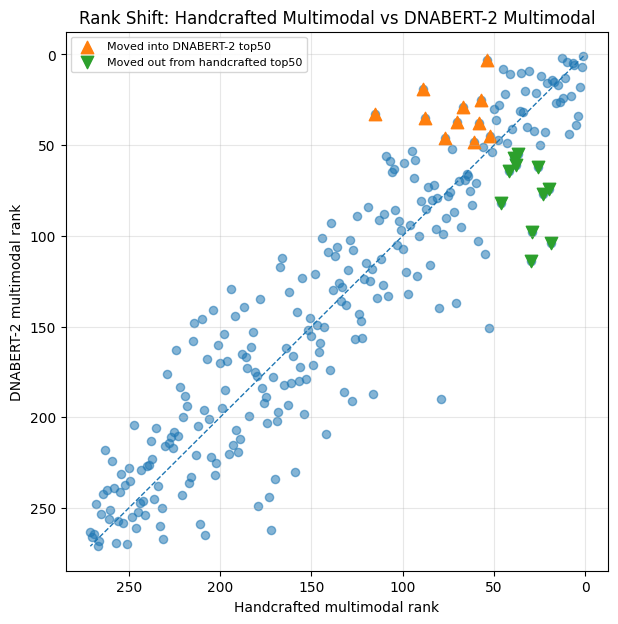

Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/figures/phase9_rank_scatter_handcrafted_vs_dnabert2.png


In [14]:
# ============================================================
# FIGURE 1 — RANK SCATTER
# x = handcrafted rank
# y = DNABERT-2 rank
# Lower rank is better.
# ============================================================

plot_df = movement_master_df.copy()

plt.figure(figsize=(7, 7))

# Background points
plt.scatter(
    plot_df["handcrafted_rank"],
    plot_df["dnabert2_rank"],
    alpha=0.55,
    s=35
)

# Diagonal
max_rank = max(plot_df["handcrafted_rank"].max(), plot_df["dnabert2_rank"].max())
plt.plot([1, max_rank], [1, max_rank], linestyle="--", linewidth=1)

# Highlight moved-in/moved-out top50
moved_in_50 = plot_df[plot_df["top50_membership"] == "moved_in_by_DNABERT2"]
moved_out_50 = plot_df[plot_df["top50_membership"] == "moved_out_from_handcrafted"]

plt.scatter(
    moved_in_50["handcrafted_rank"],
    moved_in_50["dnabert2_rank"],
    s=80,
    marker="^",
    label="Moved into DNABERT-2 top50"
)

plt.scatter(
    moved_out_50["handcrafted_rank"],
    moved_out_50["dnabert2_rank"],
    s=80,
    marker="v",
    label="Moved out from handcrafted top50"
)

plt.xlabel("Handcrafted multimodal rank")
plt.ylabel("DNABERT-2 multimodal rank")
plt.title("Rank Shift: Handcrafted Multimodal vs DNABERT-2 Multimodal")
plt.gca().invert_xaxis()
plt.gca().invert_yaxis()
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

rank_scatter_path = FIGURE_DIR / "phase9_rank_scatter_handcrafted_vs_dnabert2.png"
plt.savefig(rank_scatter_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", rank_scatter_path)

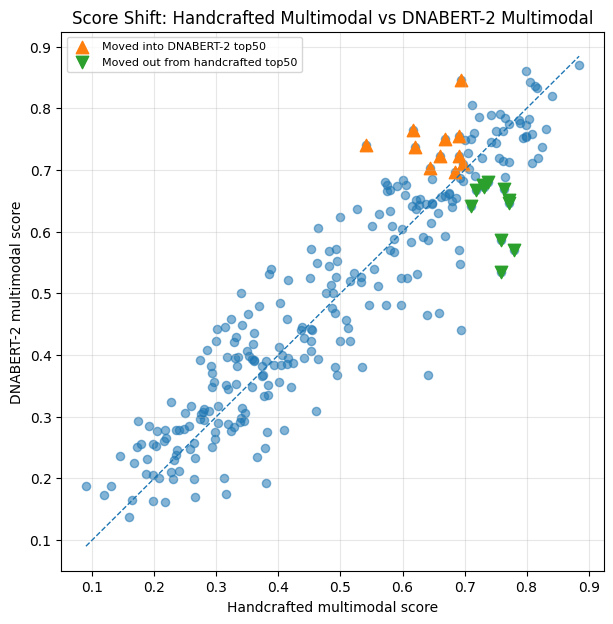

Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/figures/phase9_score_scatter_handcrafted_vs_dnabert2.png


In [15]:
# ============================================================
# FIGURE 2 — SCORE SCATTER
# ============================================================

plot_df = movement_master_df.copy()

plt.figure(figsize=(7, 7))

plt.scatter(
    plot_df["handcrafted_score"],
    plot_df["dnabert2_score"],
    alpha=0.55,
    s=35
)

# Diagonal
min_score = min(plot_df["handcrafted_score"].min(), plot_df["dnabert2_score"].min())
max_score = max(plot_df["handcrafted_score"].max(), plot_df["dnabert2_score"].max())
plt.plot([min_score, max_score], [min_score, max_score], linestyle="--", linewidth=1)

# Highlight top50 movement
plt.scatter(
    moved_in_50["handcrafted_score"],
    moved_in_50["dnabert2_score"],
    s=80,
    marker="^",
    label="Moved into DNABERT-2 top50"
)

plt.scatter(
    moved_out_50["handcrafted_score"],
    moved_out_50["dnabert2_score"],
    s=80,
    marker="v",
    label="Moved out from handcrafted top50"
)

plt.xlabel("Handcrafted multimodal score")
plt.ylabel("DNABERT-2 multimodal score")
plt.title("Score Shift: Handcrafted Multimodal vs DNABERT-2 Multimodal")
plt.legend(fontsize=8)
plt.grid(alpha=0.3)

score_scatter_path = FIGURE_DIR / "phase9_score_scatter_handcrafted_vs_dnabert2.png"
plt.savefig(score_scatter_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", score_scatter_path)

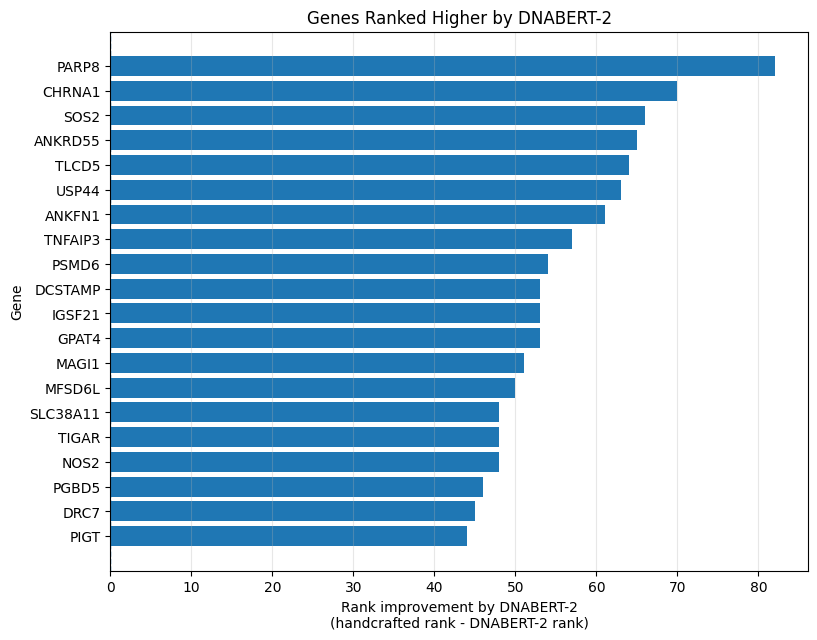

Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/figures/phase9_top_genes_ranked_higher_by_dnabert2.png


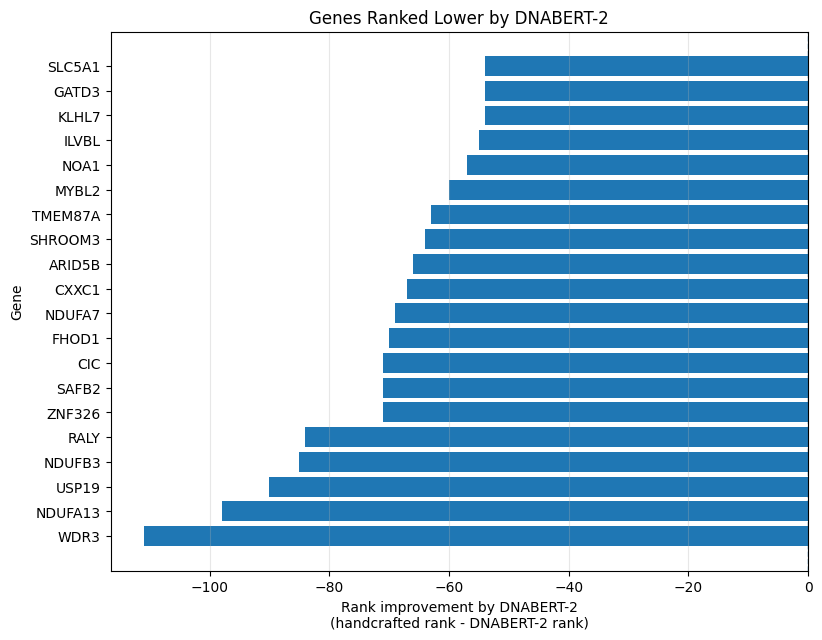

Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/figures/phase9_top_genes_ranked_lower_by_dnabert2.png


In [16]:
# ============================================================
# FIGURE 3 — TOP GENES RANKED HIGHER BY DNABERT-2
# ============================================================

def plot_rank_shift_bar(df, title, output_path, top_k=20):
    plot_df = df.head(top_k).copy()
    plot_df = plot_df.sort_values("rank_improvement_by_dnabert2", ascending=True)

    plt.figure(figsize=(9, max(5, 0.35 * len(plot_df))))
    plt.barh(plot_df["gene_symbol"], plot_df["rank_improvement_by_dnabert2"])
    plt.axvline(0, linestyle="--", linewidth=1)
    plt.xlabel("Rank improvement by DNABERT-2\n(handcrafted rank - DNABERT-2 rank)")
    plt.ylabel("Gene")
    plt.title(title)
    plt.grid(axis="x", alpha=0.3)

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)

plot_rank_shift_bar(
    dnabert2_up_df,
    title="Genes Ranked Higher by DNABERT-2",
    output_path=FIGURE_DIR / "phase9_top_genes_ranked_higher_by_dnabert2.png",
    top_k=20
)

plot_rank_shift_bar(
    dnabert2_down_df.assign(
        rank_improvement_by_dnabert2=dnabert2_down_df["rank_improvement_by_dnabert2"]
    ),
    title="Genes Ranked Lower by DNABERT-2",
    output_path=FIGURE_DIR / "phase9_top_genes_ranked_lower_by_dnabert2.png",
    top_k=20
)

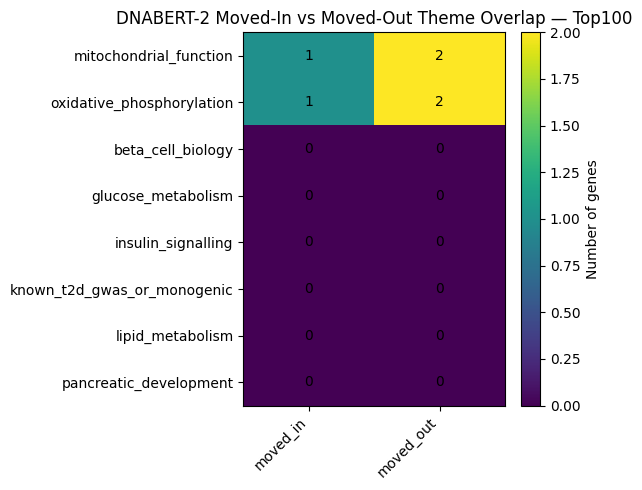

Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/figures/phase9_moved_in_out_theme_heatmap_top100.png


In [17]:
# ============================================================
# FIGURE 4 — MOVED-IN / MOVED-OUT THEME HEATMAP
# ============================================================

heatmap_df = moved_theme_df.copy()

# Keep top100 for publication readability
heatmap_100_df = heatmap_df[heatmap_df["top_n"] == 100].copy()

pivot_heatmap = heatmap_100_df.pivot_table(
    index="theme",
    columns="list_type",
    values="n_overlap",
    aggfunc="first"
).fillna(0)

# Order by moved_out, then moved_in
sort_cols = [c for c in ["moved_out", "moved_in"] if c in pivot_heatmap.columns]
pivot_heatmap = pivot_heatmap.sort_values(by=sort_cols, ascending=False)

plt.figure(figsize=(6, 5))
plt.imshow(pivot_heatmap.values, aspect="auto")

plt.xticks(
    ticks=np.arange(len(pivot_heatmap.columns)),
    labels=pivot_heatmap.columns,
    rotation=45,
    ha="right"
)

plt.yticks(
    ticks=np.arange(len(pivot_heatmap.index)),
    labels=pivot_heatmap.index
)

for i in range(pivot_heatmap.shape[0]):
    for j in range(pivot_heatmap.shape[1]):
        plt.text(j, i, int(pivot_heatmap.values[i, j]), ha="center", va="center")

plt.colorbar(label="Number of genes")
plt.title("DNABERT-2 Moved-In vs Moved-Out Theme Overlap — Top100")
plt.tight_layout()

heatmap_path = FIGURE_DIR / "phase9_moved_in_out_theme_heatmap_top100.png"
plt.savefig(heatmap_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", heatmap_path)

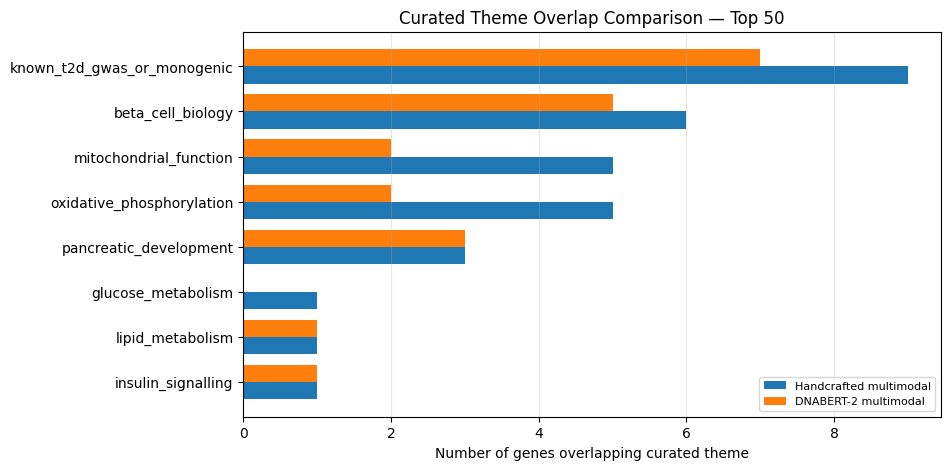

Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/figures/phase9_theme_comparison_top50.png


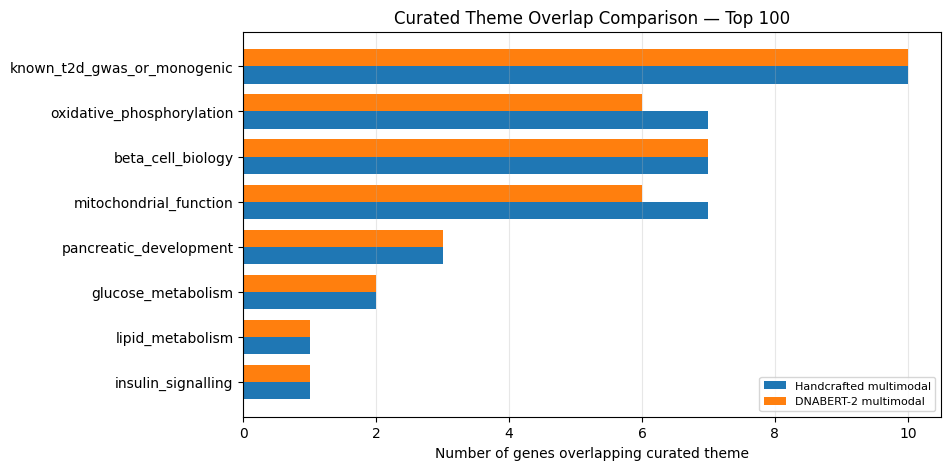

Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/figures/phase9_theme_comparison_top100.png


In [18]:
# ============================================================
# FIGURE 5 — THEME COMPARISON TOP50 AND TOP100
# ============================================================

def plot_theme_comparison(top_n, output_path):
    plot_df = theme_compare_df[theme_compare_df["top_n"] == top_n].copy()

    plot_df = plot_df.sort_values("Multimodal_handcrafted", ascending=True)

    y = np.arange(len(plot_df))
    width = 0.38

    plt.figure(figsize=(9, 5))
    plt.barh(y - width / 2, plot_df["Multimodal_handcrafted"], height=width, label="Handcrafted multimodal")
    plt.barh(y + width / 2, plot_df["Multimodal_DNABERT2"], height=width, label="DNABERT-2 multimodal")

    plt.yticks(y, plot_df["theme"])
    plt.xlabel("Number of genes overlapping curated theme")
    plt.title(f"Curated Theme Overlap Comparison — Top {top_n}")
    plt.legend(fontsize=8)
    plt.grid(axis="x", alpha=0.3)

    plt.savefig(output_path, dpi=300, bbox_inches="tight")
    plt.show()

    print("Saved:", output_path)

plot_theme_comparison(
    top_n=50,
    output_path=FIGURE_DIR / "phase9_theme_comparison_top50.png"
)

plot_theme_comparison(
    top_n=100,
    output_path=FIGURE_DIR / "phase9_theme_comparison_top100.png"
)

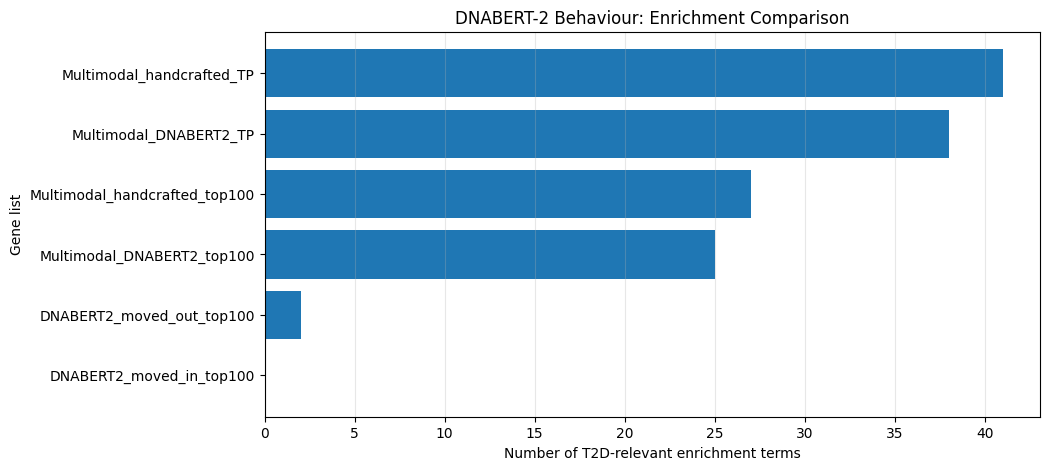

Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/figures/phase9_enrichment_comparison_t2d_relevant_terms.png


In [19]:
# ============================================================
# FIGURE 6 — ENRICHMENT COMPARISON
# ============================================================

plot_lists = [
    "Multimodal_handcrafted_top100",
    "Multimodal_DNABERT2_top100",
    "Multimodal_handcrafted_TP",
    "Multimodal_DNABERT2_TP",
    "DNABERT2_moved_in_top100",
    "DNABERT2_moved_out_top100"
]

plot_enrich_df = enrichment_summary_df[
    enrichment_summary_df["gene_list_name"].isin(plot_lists)
].copy()

plot_enrich_df = plot_enrich_df.sort_values("n_t2d_relevant_terms", ascending=True)

plt.figure(figsize=(10, 5))
plt.barh(plot_enrich_df["gene_list_name"], plot_enrich_df["n_t2d_relevant_terms"])
plt.xlabel("Number of T2D-relevant enrichment terms")
plt.ylabel("Gene list")
plt.title("DNABERT-2 Behaviour: Enrichment Comparison")
plt.grid(axis="x", alpha=0.3)

enrichment_fig_path = FIGURE_DIR / "phase9_enrichment_comparison_t2d_relevant_terms.png"
plt.savefig(enrichment_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", enrichment_fig_path)

In [20]:
# ============================================================
# SCORE/RANK MOVEMENT BY TRUE LABEL
# Does DNABERT-2 improve positive vs negative ranking differently?
# ============================================================

label_shift_summary = (
    movement_master_df
    .groupby("true_label")
    .agg(
        n=("gene_symbol", "count"),
        mean_rank_improvement_by_dnabert2=("rank_improvement_by_dnabert2", "mean"),
        median_rank_improvement_by_dnabert2=("rank_improvement_by_dnabert2", "median"),
        mean_score_delta_dnabert2_minus_handcrafted=("score_delta_dnabert2_minus_handcrafted", "mean"),
        median_score_delta_dnabert2_minus_handcrafted=("score_delta_dnabert2_minus_handcrafted", "median"),
        n_ranked_higher_by_dnabert2=("rank_direction", lambda x: (x == "DNABERT2_ranked_higher").sum()),
        n_ranked_lower_by_dnabert2=("rank_direction", lambda x: (x == "DNABERT2_ranked_lower").sum())
    )
    .reset_index()
)

label_shift_summary["label_name"] = label_shift_summary["true_label"].map({
    0: "background",
    1: "T2D-associated"
})

label_shift_summary = round_numeric_columns(label_shift_summary, 4)

display(label_shift_summary)

label_shift_path = RESULT_DIR / "phase9_rank_score_shift_by_true_label.csv"
label_shift_summary.to_csv(label_shift_path, index=False)

print("Saved:", label_shift_path)

,true_label,n,mean_rank_improvement_by_dnabert2,median_rank_improvement_by_dnabert2,mean_score_delta_dnabert2_minus_handcrafted,median_score_delta_dnabert2_minus_handcrafted,n_ranked_higher_by_dnabert2,n_ranked_lower_by_dnabert2,label_name
0,0,136,-3.7500,-2.0,-0.0033,-0.0062,62,74,background
1,1,135,3.7778,4.0,0.0081,0.0091,74,58,T2D-associated


Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_rank_score_shift_by_true_label.csv


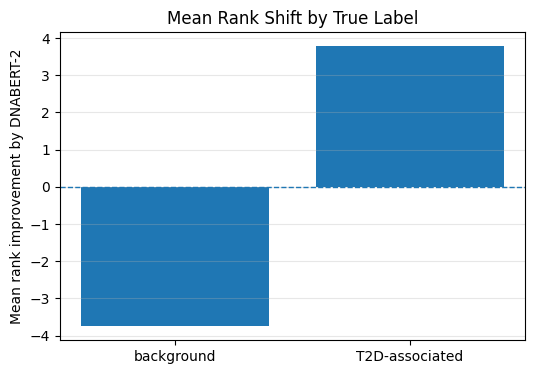

Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/figures/phase9_mean_rank_shift_by_true_label.png


In [21]:
# Figure: rank improvement by true label
plt.figure(figsize=(6, 4))

labels = label_shift_summary["label_name"].tolist()
values = label_shift_summary["mean_rank_improvement_by_dnabert2"].tolist()

plt.bar(labels, values)
plt.axhline(0, linestyle="--", linewidth=1)
plt.ylabel("Mean rank improvement by DNABERT-2")
plt.title("Mean Rank Shift by True Label")
plt.grid(axis="y", alpha=0.3)

label_shift_fig_path = FIGURE_DIR / "phase9_mean_rank_shift_by_true_label.png"
plt.savefig(label_shift_fig_path, dpi=300, bbox_inches="tight")
plt.show()

print("Saved:", label_shift_fig_path)

In [22]:
# ============================================================
# COMPACT PROFESSOR SUMMARY TABLES
# ============================================================

# Table A: main behaviour summary
tableA_records = []

# Enrichment summary values
for gene_list in [
    "Multimodal_handcrafted_top100",
    "Multimodal_DNABERT2_top100",
    "Multimodal_handcrafted_TP",
    "Multimodal_DNABERT2_TP",
    "DNABERT2_moved_in_top100",
    "DNABERT2_moved_out_top100"
]:
    sub = enrichment_summary_df[enrichment_summary_df["gene_list_name"] == gene_list]

    tableA_records.append({
        "analysis": gene_list,
        "n_input_genes": safe_first_value(sub, "n_input_genes", np.nan),
        "n_significant_terms": safe_first_value(sub, "n_significant_terms", 0),
        "n_t2d_relevant_terms": safe_first_value(sub, "n_t2d_relevant_terms", 0),
        "top_t2d_relevant_term": safe_first_value(sub, "top_t2d_relevant_term", None),
        "interpretation": ""
    })

tableA_behaviour_summary_df = pd.DataFrame(tableA_records)

# Add interpretation
tableA_behaviour_summary_df.loc[
    tableA_behaviour_summary_df["analysis"] == "Multimodal_handcrafted_top100",
    "interpretation"
] = "Handcrafted multimodal top100 retains strong mitochondrial/OXPHOS biological signal."

tableA_behaviour_summary_df.loc[
    tableA_behaviour_summary_df["analysis"] == "Multimodal_DNABERT2_top100",
    "interpretation"
] = "DNABERT-2 top100 retains T2D biology but with weaker enrichment concentration."

tableA_behaviour_summary_df.loc[
    tableA_behaviour_summary_df["analysis"] == "DNABERT2_moved_in_top100",
    "interpretation"
] = "Moved-in genes do not form a significant enriched biological cluster."

tableA_behaviour_summary_df.loc[
    tableA_behaviour_summary_df["analysis"] == "DNABERT2_moved_out_top100",
    "interpretation"
] = "Moved-out genes contain stronger mitochondrial/OXPHOS enrichment, explaining weaker DNABERT-2 biological validation."

tableA_behaviour_summary_df = round_numeric_columns(tableA_behaviour_summary_df, 4)

display(tableA_behaviour_summary_df)

tableA_path = RESULT_DIR / "phase9_professor_tableA_dnabert2_behaviour_summary.csv"
tableA_behaviour_summary_df.to_csv(tableA_path, index=False)

print("Saved:", tableA_path)

,analysis,n_input_genes,n_significant_terms,n_t2d_relevant_terms,top_t2d_relevant_term,interpretation
0,Multimodal_handcrafted_top100,100,103,27,NADH dehydrogenase complex,Handcrafted multimodal top100 retains strong mitochondrial/OXPHOS biological signal.
1,Multimodal_DNABERT2_top100,100,74,25,NADH dehydrogenase complex,DNABERT-2 top100 retains T2D biology but with weaker enrichment concentration.
2,Multimodal_handcrafted_TP,86,175,41,respiratory chain complex I,
3,Multimodal_DNABERT2_TP,88,148,38,NADH dehydrogenase (ubiquinone) activity,
4,DNABERT2_moved_in_top100,13,0,0,NaN,Moved-in genes do not form a significant enriched biological cluster.
5,DNABERT2_moved_out_top100,13,2,2,NADH dehydrogenase complex,"Moved-out genes contain stronger mitochondrial/OXPHOS enrichment, explaining weaker DNABERT-2 biological validation."


Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_professor_tableA_dnabert2_behaviour_summary.csv


In [23]:
# Table B: key moved-out and moved-in genes
key_moved_genes_df = pd.concat([
    movement_detail_tables["moved_out_top50"].assign(movement_group="moved_out_top50"),
    movement_detail_tables["moved_in_top50"].assign(movement_group="moved_in_top50")
], ignore_index=True)

key_moved_genes_df = key_moved_genes_df[[
    "movement_group",
    "gene_symbol",
    "true_label",
    "handcrafted_rank",
    "dnabert2_rank",
    "rank_improvement_by_dnabert2",
    "handcrafted_score",
    "dnabert2_score",
    "curated_biological_themes"
]]

key_moved_genes_df = round_numeric_columns(key_moved_genes_df, 4)

display(key_moved_genes_df)

tableB_path = RESULT_DIR / "phase9_professor_tableB_top50_moved_genes.csv"
key_moved_genes_df.to_csv(tableB_path, index=False)

print("Saved:", tableB_path)

,movement_group,gene_symbol,true_label,handcrafted_rank,dnabert2_rank,rank_improvement_by_dnabert2,handcrafted_score,dnabert2_score,curated_biological_themes
0,moved_out_top50,NDUFB3,1,19,104,-85,0.7789,0.5697,mitochondrial_function;oxidative_phosphorylation
1,moved_out_top50,SLC5A1,1,20,74,-54,0.7724,0.6508,glucose_metabolism;known_t2d_gwas_or_monogenic
2,moved_out_top50,GATD3,0,23,77,-54,0.7709,0.6461,
3,moved_out_top50,HMG20A,1,26,62,-36,0.7633,0.6699,
4,moved_out_top50,NDUFA7,1,29,98,-69,0.7594,0.5870,mitochondrial_function;oxidative_phosphorylation
5,moved_out_top50,RALY,1,30,114,-84,0.7581,0.5347,
6,moved_out_top50,NDUFB1,1,37,55,-18,0.7382,0.6809,mitochondrial_function;oxidative_phosphorylation
7,moved_out_top50,GRM7,0,38,61,-23,0.7320,0.6729,
8,moved_out_top50,DPP4,1,39,57,-18,0.7289,0.6765,beta_cell_biology;known_t2d_gwas_or_monogenic
9,moved_out_top50,EIF4E2,0,42,64,-22,0.7182,0.6671,


Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_professor_tableB_top50_moved_genes.csv


In [24]:
# Table C: final interpretation claims
phase9_claims_df = pd.DataFrame([
    {
        "claim": "DNABERT-2 improves global ranking performance.",
        "evidence": "Phase 7 showed DNABERT-2 multimodal achieved the highest ROC-AUC and statistically improved ROC-AUC over handcrafted multimodal.",
        "interpretation": "DNABERT-2 captures useful ranking signal across the full test set."
    },
    {
        "claim": "DNABERT-2 does not improve PR-AUC or biological enrichment over handcrafted multimodal.",
        "evidence": "Phase 7 PR-AUC difference was not significant; Phase 8/9 enrichment shows fewer significant and T2D-relevant terms for DNABERT-2 top100/TP lists.",
        "interpretation": "DNABERT-2 ranking improvement is not equivalent to stronger top-ranked biological concentration."
    },
    {
        "claim": "Handcrafted multimodal retains stronger mitochondrial/OXPHOS biological validation.",
        "evidence": "Moved-out genes include mitochondrial/OXPHOS genes such as NDUFA7, NDUFB1, NDUFB3/NDUFA13 depending on top list threshold.",
        "interpretation": "Removing these genes weakens DNABERT-2 enrichment."
    },
    {
        "claim": "DNABERT-2 top100 still preserves broad T2D biology.",
        "evidence": "Top100 curated theme counts are similar for known T2D, beta-cell biology, glucose metabolism, insulin signalling, and pancreatic development.",
        "interpretation": "DNABERT-2 does not lose diabetes biology completely; it changes ranking concentration."
    },
    {
        "claim": "Moved-in DNABERT-2 genes require separate literature review.",
        "evidence": "Moved-in genes show weak/no significant enrichment as a group.",
        "interpretation": "They may reflect different regulatory or less curated biological signals."
    }
])

display(phase9_claims_df)

claims_path = RESULT_DIR / "phase9_final_interpretation_claims.csv"
phase9_claims_df.to_csv(claims_path, index=False)

print("Saved:", claims_path)

,claim,evidence,interpretation
0,DNABERT-2 improves global ranking performance.,Phase 7 showed DNABERT-2 multimodal achieved the highest ROC-AUC and statistically improved ROC-AUC over handcrafted multimodal.,DNABERT-2 captures useful ranking signal across the full test set.
1,DNABERT-2 does not improve PR-AUC or biological enrichment over handcrafted multimodal.,Phase 7 PR-AUC difference was not significant; Phase 8/9 enrichment shows fewer significant and T2D-relevant terms for DNABERT-2 top100/TP lists.,DNABERT-2 ranking improvement is not equivalent to stronger top-ranked biological concentration.
2,Handcrafted multimodal retains stronger mitochondrial/OXPHOS biological validation.,"Moved-out genes include mitochondrial/OXPHOS genes such as NDUFA7, NDUFB1, NDUFB3/NDUFA13 depending on top list threshold.",Removing these genes weakens DNABERT-2 enrichment.
3,DNABERT-2 top100 still preserves broad T2D biology.,"Top100 curated theme counts are similar for known T2D, beta-cell biology, glucose metabolism, insulin signalling, and pancreatic development.",DNABERT-2 does not lose diabetes biology completely; it changes ranking concentration.
4,Moved-in DNABERT-2 genes require separate literature review.,Moved-in genes show weak/no significant enrichment as a group.,They may reflect different regulatory or less curated biological signals.


Saved: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_final_interpretation_claims.csv


In [25]:
# ============================================================
# EXPORT PHASE 9 EXCEL WORKBOOK
# ============================================================

excel_path = EXCEL_DIR / "phase9_dnabert2_behaviour_deep_dive_tables.xlsx"

excel_tables = {
    "Movement_Master": movement_master_df,
    "Top_List_Stability": stability_summary_df,
    "Moved_In_Top50": movement_detail_tables["moved_in_top50"],
    "Moved_Out_Top50": movement_detail_tables["moved_out_top50"],
    "Moved_In_Top100": movement_detail_tables["moved_in_top100"],
    "Moved_Out_Top100": movement_detail_tables["moved_out_top100"],
    "Theme_Movement": theme_movement_df,
    "Moved_Enrichment": moved_interpretation_df,
    "Priority_Genes": priority_gene_df,
    "Literature_Template": literature_review_template_df,
    "Label_Shift": label_shift_summary,
    "Professor_Summary": tableA_behaviour_summary_df,
    "Top50_Moved_Genes": key_moved_genes_df,
    "Claims": phase9_claims_df,
}

with pd.ExcelWriter(excel_path, engine="openpyxl") as writer:
    for sheet_name, df in excel_tables.items():
        df.to_excel(writer, sheet_name=sheet_name[:31], index=False)

print("Saved Excel:", excel_path)

Saved Excel: /content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/excel/phase9_dnabert2_behaviour_deep_dive_tables.xlsx


In [26]:
# ============================================================
# AUTO-GENERATE PHASE 9 REPORT SUMMARY
# ============================================================

# Pull values
stab50 = stability_summary_df[stability_summary_df["top_n"] == 50].iloc[0]
stab100 = stability_summary_df[stability_summary_df["top_n"] == 100].iloc[0]

moved_in100_enrich = enrichment_summary_df[
    enrichment_summary_df["gene_list_name"] == "DNABERT2_moved_in_top100"
]

moved_out100_enrich = enrichment_summary_df[
    enrichment_summary_df["gene_list_name"] == "DNABERT2_moved_out_top100"
]

hand_top100_enrich = enrichment_summary_df[
    enrichment_summary_df["gene_list_name"] == "Multimodal_handcrafted_top100"
]

dna_top100_enrich = enrichment_summary_df[
    enrichment_summary_df["gene_list_name"] == "Multimodal_DNABERT2_top100"
]

report_text = f"""
# Phase 9 — DNABERT-2 Behaviour Deep Dive Report

## Objective

Phase 9 investigated why the DNABERT-2 multimodal model achieved the highest ROC-AUC but showed weaker biological enrichment than the handcrafted multimodal model. The analysis focused on rank shifts, score shifts, moved-in/moved-out genes, biological theme changes, and enrichment differences.

## Top-List Stability

Top-50 comparison:
- Shared genes: {int(stab50['shared_n'])}
- DNABERT-2 moved-in genes: {int(stab50['moved_in_by_DNABERT2_n'])}
- Handcrafted moved-out genes: {int(stab50['moved_out_from_handcrafted_n'])}
- Jaccard overlap: {float(stab50['jaccard_top_list']):.4f}

Top-100 comparison:
- Shared genes: {int(stab100['shared_n'])}
- DNABERT-2 moved-in genes: {int(stab100['moved_in_by_DNABERT2_n'])}
- Handcrafted moved-out genes: {int(stab100['moved_out_from_handcrafted_n'])}
- Jaccard overlap: {float(stab100['jaccard_top_list']):.4f}

The top-100 list is more stable than the top-50 list, suggesting that DNABERT-2 does not completely change the candidate space but changes the ordering of the highest-ranked genes.

## Enrichment Behaviour

Handcrafted multimodal top100:
- Significant terms: {safe_first_value(hand_top100_enrich, 'n_significant_terms', 0)}
- T2D-relevant terms: {safe_first_value(hand_top100_enrich, 'n_t2d_relevant_terms', 0)}
- Top relevant term: {safe_first_value(hand_top100_enrich, 'top_t2d_relevant_term', None)}

DNABERT-2 multimodal top100:
- Significant terms: {safe_first_value(dna_top100_enrich, 'n_significant_terms', 0)}
- T2D-relevant terms: {safe_first_value(dna_top100_enrich, 'n_t2d_relevant_terms', 0)}
- Top relevant term: {safe_first_value(dna_top100_enrich, 'top_t2d_relevant_term', None)}

DNABERT-2 moved-in top100:
- Significant terms: {safe_first_value(moved_in100_enrich, 'n_significant_terms', 0)}
- T2D-relevant terms: {safe_first_value(moved_in100_enrich, 'n_t2d_relevant_terms', 0)}

DNABERT-2 moved-out top100:
- Significant terms: {safe_first_value(moved_out100_enrich, 'n_significant_terms', 0)}
- T2D-relevant terms: {safe_first_value(moved_out100_enrich, 'n_t2d_relevant_terms', 0)}
- Top relevant term: {safe_first_value(moved_out100_enrich, 'top_t2d_relevant_term', None)}

## Interpretation

DNABERT-2 improves global ranking performance, but its moved-in genes do not form a strong enriched T2D-related biological cluster. In contrast, several genes moved out of the handcrafted top-ranked list belong to mitochondrial function, oxidative phosphorylation, glucose metabolism, or known T2D biology. This explains why DNABERT-2 can improve ROC-AUC while showing weaker biological enrichment.

## Main Conclusion

DNABERT-2 captures useful ranking information across the full test set, which explains its higher ROC-AUC. However, the handcrafted genomic features preserve a more concentrated mitochondrial/OXPHOS and curated T2D biological signal among the highest-ranked genes. Therefore, DNABERT-2 should be interpreted as a statistically useful ranking extension, while the handcrafted multimodal model remains the stronger biologically interpretable model.
"""

report_path = REPORT_DIR / "phase9_dnabert2_behaviour_deep_dive_summary.md"

with open(report_path, "w") as f:
    f.write(report_text)

print(report_text)
print("Saved report:", report_path)


# Phase 9 — DNABERT-2 Behaviour Deep Dive Report

## Objective

Phase 9 investigated why the DNABERT-2 multimodal model achieved the highest ROC-AUC but showed weaker biological enrichment than the handcrafted multimodal model. The analysis focused on rank shifts, score shifts, moved-in/moved-out genes, biological theme changes, and enrichment differences.

## Top-List Stability

Top-50 comparison:
- Shared genes: 39
- DNABERT-2 moved-in genes: 11
- Handcrafted moved-out genes: 11
- Jaccard overlap: 0.6393

Top-100 comparison:
- Shared genes: 87
- DNABERT-2 moved-in genes: 13
- Handcrafted moved-out genes: 13
- Jaccard overlap: 0.7699

The top-100 list is more stable than the top-50 list, suggesting that DNABERT-2 does not completely change the candidate space but changes the ordering of the highest-ranked genes.

## Enrichment Behaviour

Handcrafted multimodal top100:
- Significant terms: 103
- T2D-relevant terms: 27
- Top relevant term: NADH dehydrogenase complex

DNABERT-2 multimod

In [27]:
# ============================================================
# LIST PHASE 9 OUTPUTS
# ============================================================

print("=== RESULT FILES ===")
for p in sorted(RESULT_DIR.glob("*")):
    print(p)

print("\n=== FIGURE FILES ===")
for p in sorted(FIGURE_DIR.glob("*")):
    print(p)

print("\n=== EXCEL FILES ===")
for p in sorted(EXCEL_DIR.glob("*")):
    print(p)

print("\n=== REPORT FILES ===")
for p in sorted(REPORT_DIR.glob("*")):
    print(p)

print("\n=== GENE LIST FILES ===")
for p in sorted(GENE_LIST_DIR.glob("*")):
    print(p)

=== RESULT FILES ===
/content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_final_interpretation_claims.csv
/content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_literature_review_template_moved_in_out_genes.csv
/content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_moved_in_genes_top100.csv
/content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_moved_in_genes_top50.csv
/content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_moved_in_out_enrichment_summary.csv
/content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_moved_in_out_interpretation_table.csv
/content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_deep_dive/results/phase9_moved_out_genes_top100.csv
/content/drive/MyDrive/Project_Protein/model/phase9_dnabert2_behaviour_de

In [28]:
display(stability_summary_df)
display(moved_interpretation_df)
display(theme_movement_df)
display(priority_gene_df)
display(phase9_claims_df)
display(label_shift_summary)

,top_n,shared_n,moved_in_by_DNABERT2_n,moved_out_from_handcrafted_n,outside_both_n,jaccard_top_list,interpretation
0,50,39,11,11,210,0.6393,top list moderately changed
1,100,87,13,13,158,0.7699,top list largely stable


,top_n,group,n_genes,n_curated_theme_supported_genes,curated_theme_supported_genes,n_significant_terms,n_t2d_relevant_terms,top_t2d_relevant_term,interpretation
0,50,moved_in_by_DNABERT2,11,0,,9,0,NaN,DNABERT-2 moved-in genes do not form a strong curated/enriched T2D biological cluster
1,50,moved_out_from_handcrafted,11,5,NDUFB3;SLC5A1;NDUFA7;NDUFB1;DPP4,37,19,respiratory chain complex I,"Genes moved out by DNABERT-2 contain stronger curated/enriched mitochondrial, OXPHOS, glucose, or T2D biology"
2,100,moved_in_by_DNABERT2,13,1,NDUFA9,0,0,NaN,DNABERT-2 moved-in genes do not form a strong curated/enriched T2D biological cluster
3,100,moved_out_from_handcrafted,13,2,NDUFB3;NDUFA13,2,2,NADH dehydrogenase complex,"Genes moved out by DNABERT-2 contain stronger curated/enriched mitochondrial, OXPHOS, glucose, or T2D biology"


,top_n,theme,n_theme_genes_in_test,shared_n,moved_in_by_DNABERT2_n,moved_out_from_handcrafted_n,net_moved_in_minus_out,mean_rank_improvement_by_dnabert2,median_rank_improvement_by_dnabert2,moved_in_genes,moved_out_genes,shared_genes
0,50,mitochondrial_function,10,2,0,3,-3,-21.6000,-8.5,,NDUFB3;NDUFA7;NDUFB1,NDUFB2;NDUFV1
1,50,oxidative_phosphorylation,10,2,0,3,-3,-21.6000,-8.5,,NDUFB3;NDUFA7;NDUFB1,NDUFB2;NDUFV1
2,50,known_t2d_gwas_or_monogenic,14,7,0,2,-2,-11.2143,-4.0,,SLC5A1;DPP4,NEUROD1;IGF2BP2;HHEX;CACNA1D;GAD1;PDX1;INSR
3,50,beta_cell_biology,9,5,0,1,-1,-4.8889,1.0,,DPP4,NEUROD1;ISL1;CACNA1D;GAD1;PDX1
4,50,glucose_metabolism,3,0,0,1,-1,-8.6667,-3.0,,SLC5A1,
5,50,insulin_signalling,1,1,0,0,0,0.0000,0.0,,,INSR
6,50,lipid_metabolism,1,1,0,0,0,5.0000,5.0,,,SCD5
7,50,pancreatic_development,4,3,0,0,0,-10.2500,-6.5,,,NEUROD1;ISL1;PDX1
8,100,mitochondrial_function,10,5,1,2,-1,-21.6000,-8.5,NDUFA9,NDUFA13;NDUFB3,NDUFA7;NDUFB1;NDUFB2;NDUFC2;NDUFV1
9,100,oxidative_phosphorylation,10,5,1,2,-1,-21.6000,-8.5,NDUFA9,NDUFA13;NDUFB3,NDUFA7;NDUFB1;NDUFB2;NDUFC2;NDUFV1


,gene_symbol,true_label,phase9_gene_role,handcrafted_rank,dnabert2_rank,rank_improvement_by_dnabert2,handcrafted_score,dnabert2_score,score_delta_dnabert2_minus_handcrafted,top50_membership,top100_membership,curated_biological_themes,phase9_interpretation_to_use
0,ARF5,1,DNABERT2_moved_in_top100,101,97,4,0.5855,0.5889,0.0034,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
1,HCFC2,0,DNABERT2_moved_in_top100,102,92,10,0.5826,0.6086,0.0261,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
2,AFAP1L2,1,DNABERT2_moved_in_top100,104,86,18,0.5795,0.6336,0.0541,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
3,SCTR,1,DNABERT2_moved_in_top100,105,63,42,0.5795,0.6683,0.0889,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
4,TBC1D8,0,DNABERT2_moved_in_top100,106,65,41,0.5757,0.6665,0.0909,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
5,SLC38A11,1,DNABERT2_moved_in_top100,107,59,48,0.5754,0.6757,0.1004,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
6,GPAT4,1,DNABERT2_moved_in_top100,109,56,53,0.5723,0.6808,0.1085,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
7,TENT5C,1,DNABERT2_moved_in_top100,110,88,22,0.5615,0.6291,0.0676,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
8,TMEM106B,1,DNABERT2_moved_in_top100,113,91,22,0.5510,0.6090,0.0580,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.
9,PELO,1,DNABERT2_moved_in_top100,119,84,35,0.5269,0.6364,0.1095,outside_both,moved_in_by_DNABERT2,,DNABERT-2 moved this gene into the top-100. Literature review is needed to determine whether this represents additional regulatory signal.


,claim,evidence,interpretation
0,DNABERT-2 improves global ranking performance.,Phase 7 showed DNABERT-2 multimodal achieved the highest ROC-AUC and statistically improved ROC-AUC over handcrafted multimodal.,DNABERT-2 captures useful ranking signal across the full test set.
1,DNABERT-2 does not improve PR-AUC or biological enrichment over handcrafted multimodal.,Phase 7 PR-AUC difference was not significant; Phase 8/9 enrichment shows fewer significant and T2D-relevant terms for DNABERT-2 top100/TP lists.,DNABERT-2 ranking improvement is not equivalent to stronger top-ranked biological concentration.
2,Handcrafted multimodal retains stronger mitochondrial/OXPHOS biological validation.,"Moved-out genes include mitochondrial/OXPHOS genes such as NDUFA7, NDUFB1, NDUFB3/NDUFA13 depending on top list threshold.",Removing these genes weakens DNABERT-2 enrichment.
3,DNABERT-2 top100 still preserves broad T2D biology.,"Top100 curated theme counts are similar for known T2D, beta-cell biology, glucose metabolism, insulin signalling, and pancreatic development.",DNABERT-2 does not lose diabetes biology completely; it changes ranking concentration.
4,Moved-in DNABERT-2 genes require separate literature review.,Moved-in genes show weak/no significant enrichment as a group.,They may reflect different regulatory or less curated biological signals.


,true_label,n,mean_rank_improvement_by_dnabert2,median_rank_improvement_by_dnabert2,mean_score_delta_dnabert2_minus_handcrafted,median_score_delta_dnabert2_minus_handcrafted,n_ranked_higher_by_dnabert2,n_ranked_lower_by_dnabert2,label_name
0,0,136,-3.7500,-2.0,-0.0033,-0.0062,62,74,background
1,1,135,3.7778,4.0,0.0081,0.0091,74,58,T2D-associated
